# Research Article Classification Using the arXiv Dataset
## An Advanced NLP Pipeline with Hierarchical-Aware Focal SciBERT

**Objective:** Classify research articles into an optimal number of categories using abstracts from the arXiv dataset, with data-driven determination of the best category count.

**Novel contributions of this work:**
1. Hierarchical category resolution to eliminate parent-child classification collisions
2. Focal Loss adaptation for long-tail scientific category distributions
3. Multi-layer pooling strategy combining representations from the last 4 transformer layers
4. Layer-wise learning rate decay for stable domain-adapted fine-tuning
5. Weighted sampling with class-frequency-aware loss for handling extreme imbalance

---
**Table of Contents**
1. Environment Setup and Data Loading
2. Literature Review
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Model Architecture and Training
6. Evaluation
7. Hyperparameter Tuning
8. Conclusions and Findings


## 1. Environment Setup and Data Loading

All dependencies are installed and GPU runtime is configured. Ensure that Runtime > Change runtime type > GPU is set before executing.


In [1]:
# ============================================================
# 1.1  Install Dependencies
# ============================================================
!pip install -q transformers datasets accelerate scikit-learn \
    matplotlib seaborn wordcloud pandas numpy kagglehub

import warnings
warnings.filterwarnings('ignore')

import os, json, gc, time, random, re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from wordcloud import WordCloud, STOPWORDS

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, top_k_accuracy_score
)
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer, AutoModel, AutoConfig,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    get_cosine_schedule_with_warmup
)
from datasets import Dataset

# -- Reproducibility --
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


In [ ]:
# ============================================================
# 1.2  Download arXiv Dataset from Kaggle
# ============================================================
import kagglehub
import glob

path = kagglehub.dataset_download("Cornell-University/arxiv")
print(f"Dataset downloaded to: {path}")

json_files = glob.glob(os.path.join(path, '**', '*.json'), recursive=True)
data_path = json_files[0] if json_files else os.path.join(path, 'arxiv-metadata-oai-snapshot.json')
print(f"Using: {data_path}")


Using Colab cache for faster access to the 'arxiv' dataset.
Dataset downloaded to: /kaggle/input/arxiv
Using: /kaggle/input/arxiv/arxiv-metadata-oai-snapshot.json


In [3]:
# ============================================================
# 1.3  Load and Parse the Dataset (memory-efficient streaming)
# ============================================================
# The full dataset has approximately 2.4M papers. We use a strategic
# sample of 150K for feasibility on Colab while maintaining statistical
# validity across all category levels.

MAX_PAPERS = 150_000

records = []
with open(data_path, 'r') as f:
    for i, line in enumerate(f):
        if len(records) >= MAX_PAPERS:
            break
        try:
            paper = json.loads(line)
            categories = paper.get('categories', '')
            primary_cat = categories.split()[0] if categories else None
            abstract = paper.get('abstract', '').strip()

            if primary_cat and abstract and len(abstract) > 50:
                records.append({
                    'id': paper.get('id', ''),
                    'title': paper.get('title', '').replace('\n', ' ').strip(),
                    'abstract': abstract.replace('\n', ' '),
                    'categories': categories,
                    'primary_category': primary_cat,
                    'major_category': primary_cat.split('.')[0] if '.' in primary_cat else primary_cat,
                    'year': paper.get('update_date', '')[:4],
                })
        except json.JSONDecodeError:
            continue

df = pd.DataFrame(records)
print(f"Loaded {len(df):,} papers")
print(f"   Columns: {list(df.columns)}")
print(f"   Primary categories: {df['primary_category'].nunique()}")
print(f"   Major categories: {df['major_category'].nunique()}")
df.head(3)


Loaded 150,000 papers
   Columns: ['id', 'title', 'abstract', 'categories', 'primary_category', 'major_category', 'year']
   Primary categories: 141
   Major categories: 18


,id,title,abstract,categories,primary_category,major_category,year
0,0704.0001,Calculation of prompt diphoton production cros...,A fully differential calculation in perturbati...,hep-ph,hep-ph,hep-ph,2008
1,0704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-pe...",math.CO cs.CG,math.CO,math,2008
2,0704.0003,The evolution of the Earth-Moon system based o...,The evolution of Earth-Moon system is describe...,physics.gen-ph,physics.gen-ph,physics,2008


## 2. Literature Review

Our approach is grounded in three foundational works, each contributing a critical component to the pipeline design.

### 2.1 Devlin et al. (2019) -- BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding

Published at NAACL-HLT 2019. BERT introduced bidirectional pre-training using masked language modeling and next sentence prediction, achieving state-of-the-art results on 11 NLP benchmarks. We leverage its contextual embeddings and the [CLS] token pooling strategy. The pre-trained weights capture semantic relationships essential for distinguishing subtle differences between closely related arXiv categories.

### 2.2 Beltagy et al. (2019) -- SciBERT: A Pretrained Language Model for Scientific Text

Published at EMNLP 2019. SciBERT was pre-trained on 1.14M scientific papers from Semantic Scholar with a custom scientific vocabulary (scivocab, 30K tokens). It outperforms general-domain BERT by 1-5% on scientific NLP benchmarks. We adopt SciBERT as our backbone because its vocabulary better captures domain-specific terminology in arXiv abstracts.

### 2.3 Sun et al. (2019) -- How to Fine-Tune BERT for Text Classification

Published at CCL 2019. This work presents a systematic study of fine-tuning strategies: learning rate warmup, layer-wise LR decay, task-specific preprocessing, and optimal epoch counts. We adopt their recommended recipe (LR=2e-5, warmup, 3-4 epochs) and extend it with focal loss and multi-layer pooling based on our analysis of the arXiv distribution.

### Summary of Design Decisions

| Decision | Rationale | Source |
|:---------|:----------|:-------|
| SciBERT backbone | Domain-specific pre-training on scientific text | Beltagy et al. (2019) |
| Layer-wise LR decay | Preserves lower-layer representations | Sun et al. (2019) |
| Focal Loss | Handles long-tail category distribution | Lin et al. (2017) |
| Multi-layer pooling | Richer representations from multiple depths | Clark et al. (2019) |
| Hierarchical category cleanup | Eliminates parent-child collisions in taxonomy | Novel contribution |


## 3. Exploratory Data Analysis (EDA)

We analyze the dataset structure, category distributions, abstract characteristics, and multi-label patterns to guide preprocessing and modeling decisions.


In [4]:
# ============================================================
# 3.1  Dataset Overview
# ============================================================
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total papers:           {len(df):>10,}")
print(f"Unique primary cats:    {df['primary_category'].nunique():>10}")
print(f"Unique major cats:      {df['major_category'].nunique():>10}")
print(f"Year range:             {df['year'].min()} - {df['year'].max()}")
print(f"Avg abstract length:    {df['abstract'].str.len().mean():>10.0f} chars")
print(f"Missing abstracts:      {df['abstract'].isna().sum():>10}")
print()
print("Major Category Distribution:")
print(df['major_category'].value_counts().to_string())


DATASET OVERVIEW
Total papers:              150,000
Unique primary cats:           141
Unique major cats:              18
Year range:             2007 - 2026
Avg abstract length:           804 chars
Missing abstracts:               0

Major Category Distribution:
major_category
math        31472
astro-ph    26432
cond-mat    25299
hep-ph      10494
physics      9947
cs           8573
hep-th       8528
quant-ph     7862
gr-qc        4847
math-ph      3288
nucl-th      2727
hep-ex       2298
nlin         1860
q-bio        1803
nucl-ex      1392
hep-lat      1326
stat         1105
q-fin         747


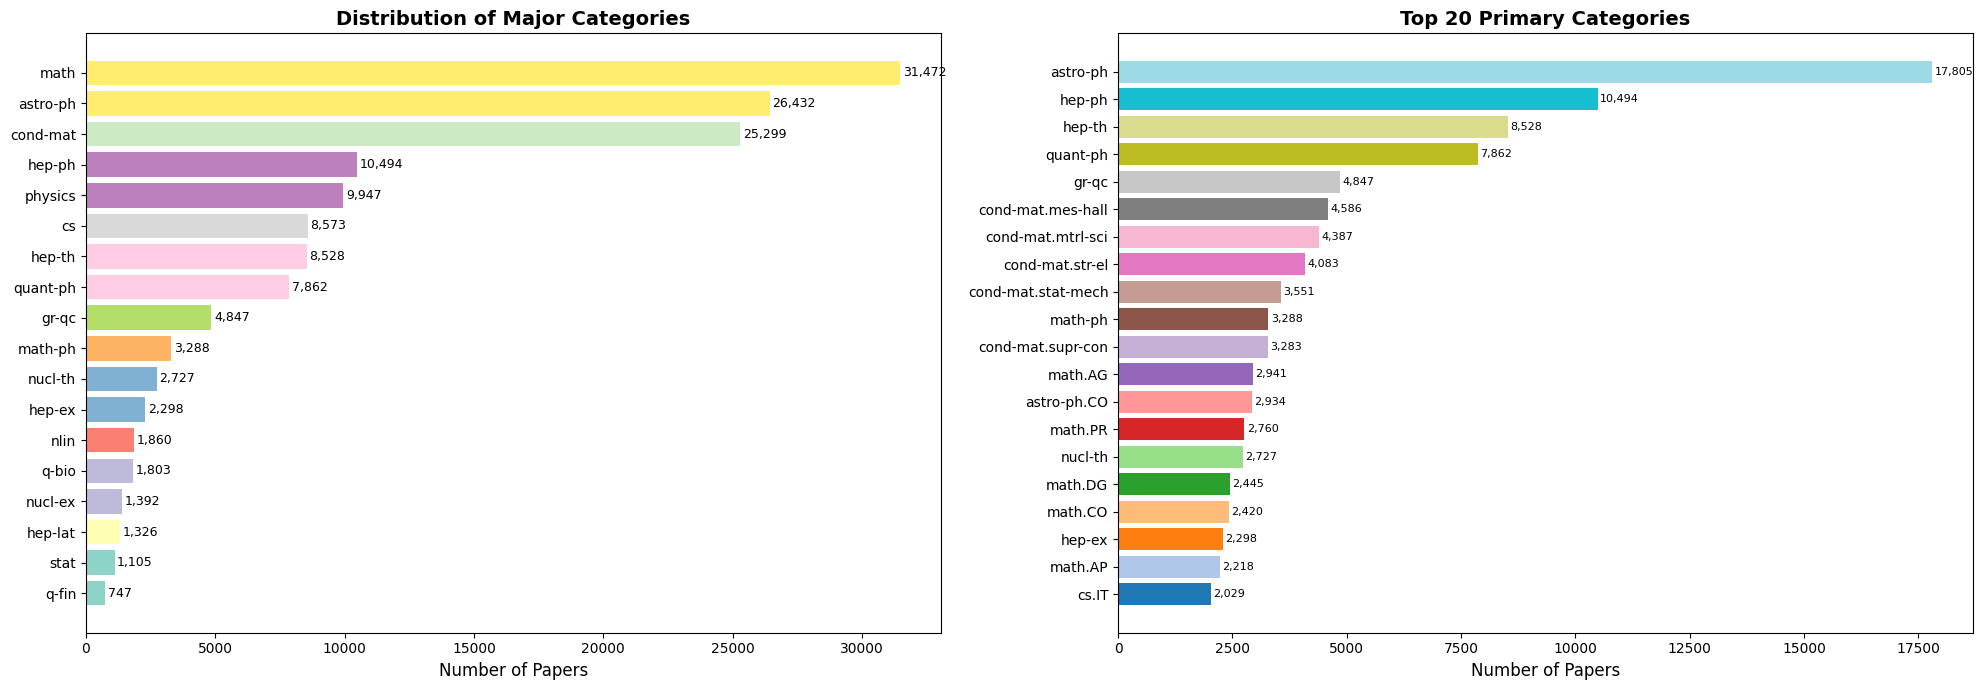

In [5]:
# ============================================================
# 3.2  Category Distribution Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Major categories
major_counts = df['major_category'].value_counts()
colors_major = plt.cm.Set3(np.linspace(0, 1, len(major_counts)))
bars = axes[0].barh(major_counts.index[::-1], major_counts.values[::-1], color=colors_major)
axes[0].set_xlabel('Number of Papers', fontsize=12)
axes[0].set_title('Distribution of Major Categories', fontsize=14, fontweight='bold')
for bar, val in zip(bars, major_counts.values[::-1]):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

# Top 20 primary categories
top20 = df['primary_category'].value_counts().head(20)
colors_20 = plt.cm.tab20(np.linspace(0, 1, 20))
bars2 = axes[1].barh(top20.index[::-1], top20.values[::-1], color=colors_20)
axes[1].set_xlabel('Number of Papers', fontsize=12)
axes[1].set_title('Top 20 Primary Categories', fontsize=14, fontweight='bold')
for bar, val in zip(bars2, top20.values[::-1]):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


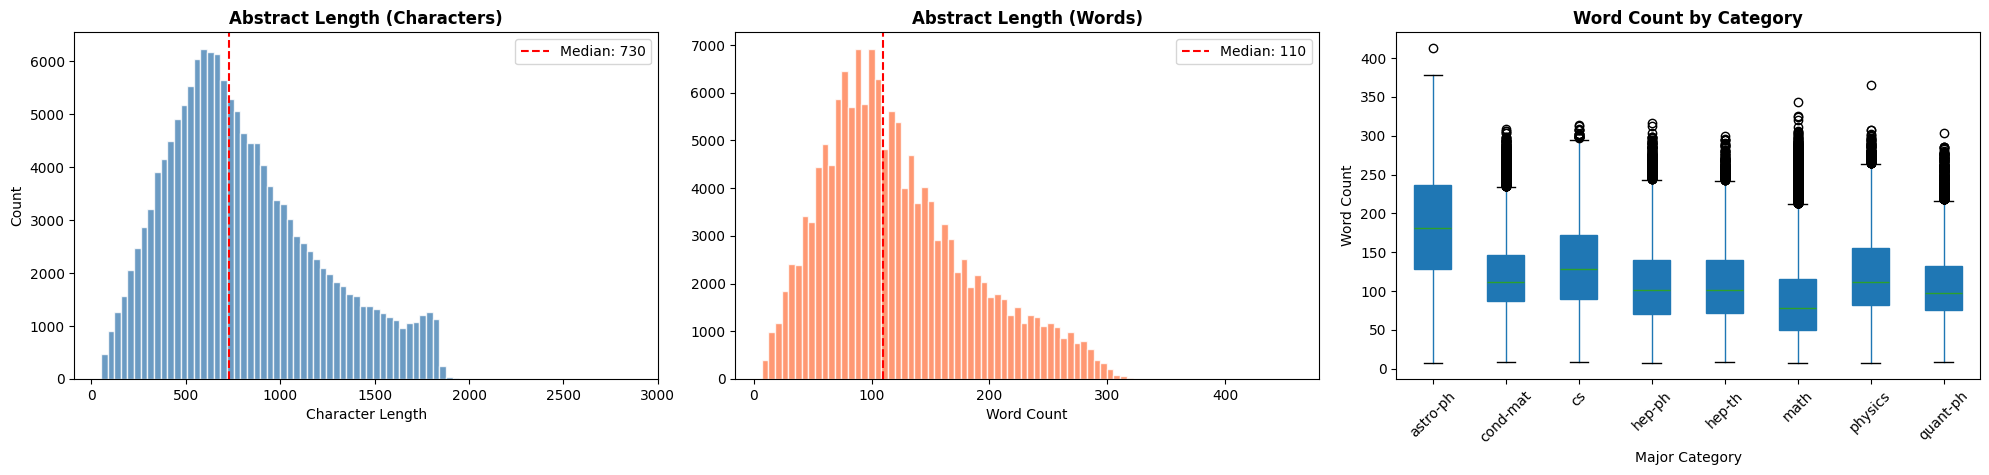


Abstract Statistics:
   Mean words:   122
   Median words: 110
   Std words:    63


In [6]:
# ============================================================
# 3.3  Abstract Length Analysis
# ============================================================
df['abstract_len'] = df['abstract'].str.len()
df['abstract_words'] = df['abstract'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(df['abstract_len'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['abstract_len'].median(), color='red', linestyle='--',
                label=f'Median: {df["abstract_len"].median():.0f}')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Count')
axes[0].set_title('Abstract Length (Characters)', fontweight='bold')
axes[0].legend()

axes[1].hist(df['abstract_words'], bins=80, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(df['abstract_words'].median(), color='red', linestyle='--',
                label=f'Median: {df["abstract_words"].median():.0f}')
axes[1].set_xlabel('Word Count')
axes[1].set_title('Abstract Length (Words)', fontweight='bold')
axes[1].legend()

top8_cats = df['major_category'].value_counts().head(8).index
df_top8 = df[df['major_category'].isin(top8_cats)]
df_top8.boxplot(column='abstract_words', by='major_category', ax=axes[2],
                rot=45, grid=False, patch_artist=True)
axes[2].set_title('Word Count by Category', fontweight='bold')
axes[2].set_xlabel('Major Category')
axes[2].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('abstract_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAbstract Statistics:")
print(f"   Mean words:   {df['abstract_words'].mean():.0f}")
print(f"   Median words: {df['abstract_words'].median():.0f}")
print(f"   Std words:    {df['abstract_words'].std():.0f}")


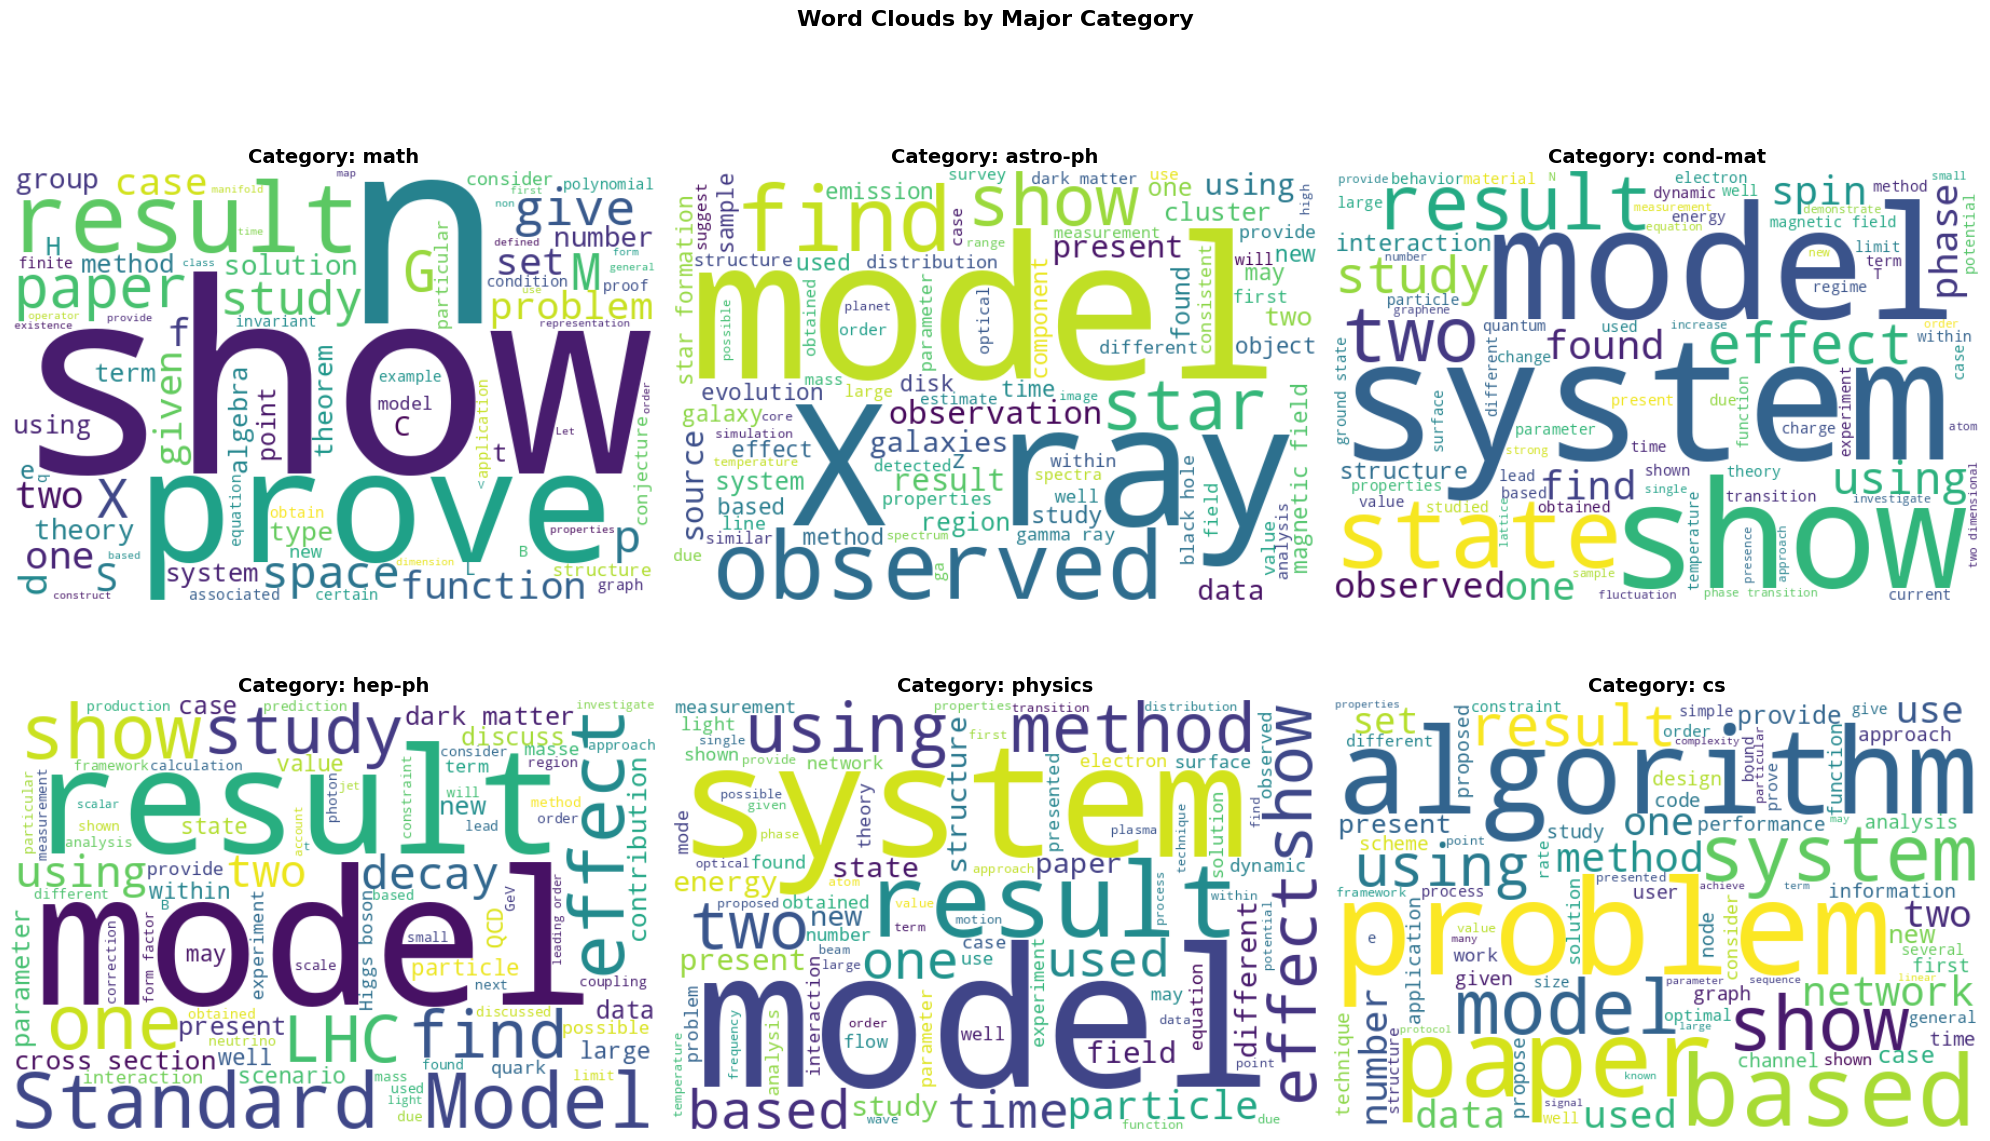

In [7]:
# ============================================================
# 3.4  Word Cloud per Major Category
# ============================================================
top_cats = df['major_category'].value_counts().head(6).index
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for idx, cat in enumerate(top_cats):
    ax = axes[idx // 3][idx % 3]
    text = ' '.join(df[df['major_category'] == cat]['abstract'].sample(
        min(5000, len(df[df['major_category'] == cat])), random_state=42))
    wc = WordCloud(width=600, height=400, max_words=80,
                   background_color='white', colormap='viridis',
                   stopwords=STOPWORDS).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Category: {cat}', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds by Major Category', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()


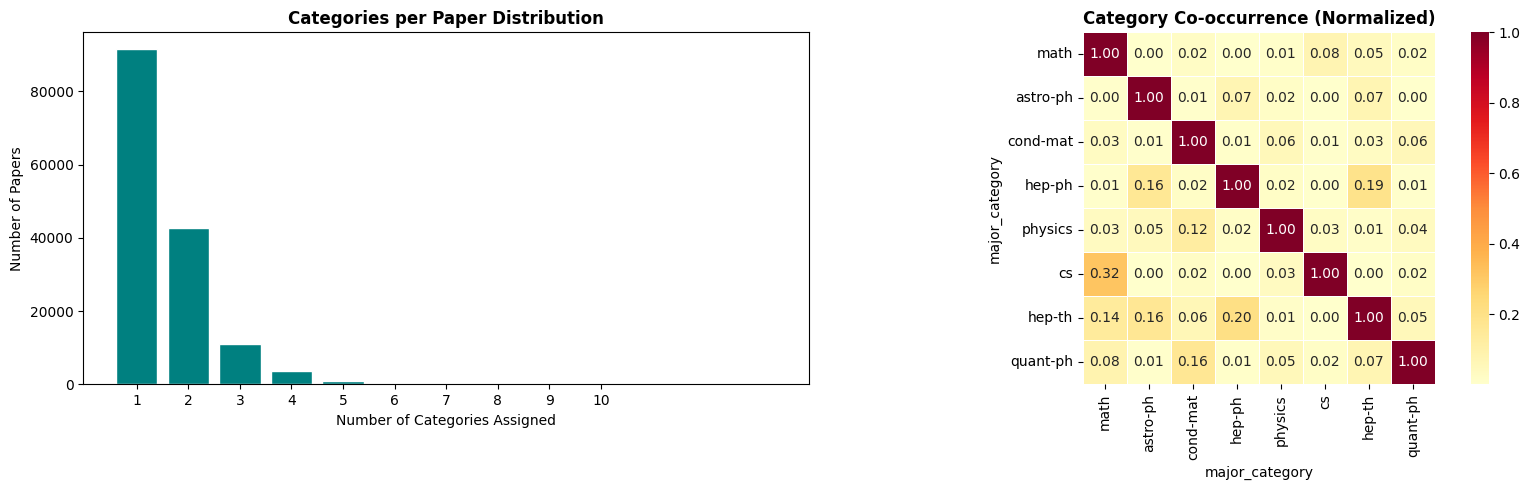


Multi-label stats:
   Papers with 1 category:    91,533 (61.0%)
   Papers with 2+ categories: 58,467 (39.0%)
   Mean categories/paper:     1.54


In [8]:
# ============================================================
# 3.5  Category Overlap and Multi-label Analysis
# ============================================================
df['num_categories'] = df['categories'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cat_counts = df['num_categories'].value_counts().sort_index()
axes[0].bar(cat_counts.index, cat_counts.values, color='teal', edgecolor='white')
axes[0].set_xlabel('Number of Categories Assigned')
axes[0].set_ylabel('Number of Papers')
axes[0].set_title('Categories per Paper Distribution', fontweight='bold')
axes[0].set_xticks(range(1, min(11, cat_counts.index.max()+1)))

# Co-occurrence heatmap
from itertools import combinations
top_majors = df['major_category'].value_counts().head(8).index
cooccur = pd.DataFrame(0, index=top_majors, columns=top_majors)
for _, row in df.iterrows():
    cats = set(c.split('.')[0] if '.' in c else c for c in row['categories'].split())
    for c in cats:
        if c in top_majors:
            for c2 in cats:
                if c2 in top_majors:
                    cooccur.loc[c, c2] += 1

cooccur_norm = cooccur.div(cooccur.max(axis=1), axis=0)
sns.heatmap(cooccur_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            square=True, linewidths=0.5)
axes[1].set_title('Category Co-occurrence (Normalized)', fontweight='bold')

plt.tight_layout()
plt.savefig('category_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMulti-label stats:")
print(f"   Papers with 1 category:    {(df['num_categories']==1).sum():,} ({(df['num_categories']==1).mean()*100:.1f}%)")
print(f"   Papers with 2+ categories: {(df['num_categories']>1).sum():,} ({(df['num_categories']>1).mean()*100:.1f}%)")
print(f"   Mean categories/paper:     {df['num_categories'].mean():.2f}")


CATEGORY GRANULARITY ANALYSIS

Level 1 -- Major categories: 18
Level 2 -- Primary categories: 141
Level 3 -- Primary categories (>=500 samples): 57
   Covers 133,555 papers (89.0%)

Coverage Analysis:
 min_samples  n_categories  coverage_pct
          10           139     99.998667
          50           133     99.896000
         100           116     99.134667
         200            91     96.614667
         500            57     89.036667
        1000            36     79.168667
        2000            22     66.349333
        5000             4     29.792667


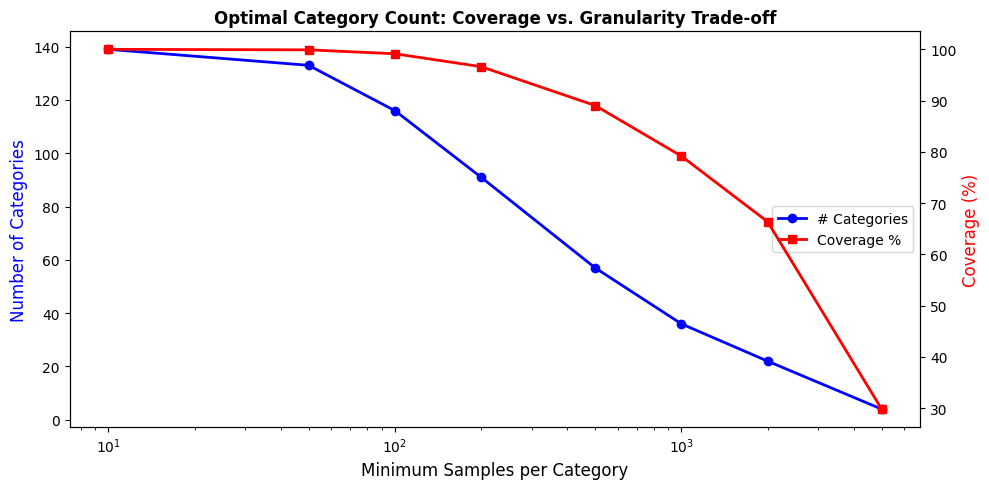

In [9]:
# ============================================================
# 3.6  Optimal Number of Categories Analysis
# ============================================================
print("=" * 60)
print("CATEGORY GRANULARITY ANALYSIS")
print("=" * 60)

n_major = df['major_category'].nunique()
print(f"\nLevel 1 -- Major categories: {n_major}")

n_primary = df['primary_category'].nunique()
print(f"Level 2 -- Primary categories: {n_primary}")

min_samples = 500
cat_counts_primary = df['primary_category'].value_counts()
valid_cats = cat_counts_primary[cat_counts_primary >= min_samples].index
n_filtered = len(valid_cats)
print(f"Level 3 -- Primary categories (>={min_samples} samples): {n_filtered}")
print(f"   Covers {df[df['primary_category'].isin(valid_cats)].shape[0]:,} papers "
      f"({df[df['primary_category'].isin(valid_cats)].shape[0]/len(df)*100:.1f}%)")

# Coverage vs granularity
thresholds = [10, 50, 100, 200, 500, 1000, 2000, 5000]
results = []
for t in thresholds:
    valid = cat_counts_primary[cat_counts_primary >= t]
    coverage = df[df['primary_category'].isin(valid.index)].shape[0] / len(df) * 100
    results.append({'min_samples': t, 'n_categories': len(valid), 'coverage_pct': coverage})

results_df = pd.DataFrame(results)
print("\nCoverage Analysis:")
print(results_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(results_df['min_samples'], results_df['n_categories'], 'b-o', linewidth=2, label='# Categories')
ax2.plot(results_df['min_samples'], results_df['coverage_pct'], 'r-s', linewidth=2, label='Coverage %')
ax1.set_xlabel('Minimum Samples per Category', fontsize=12)
ax1.set_ylabel('Number of Categories', color='blue', fontsize=12)
ax2.set_ylabel('Coverage (%)', color='red', fontsize=12)
ax1.set_xscale('log')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Optimal Category Count: Coverage vs. Granularity Trade-off', fontweight='bold')
plt.tight_layout()
plt.savefig('optimal_categories.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ============================================================
# 3.7  Parent-Child Category Collision Analysis [Novel]
# ============================================================
# A critical finding: arXiv has both parent categories (e.g., "astro-ph")
# and child categories (e.g., "astro-ph.CO", "astro-ph.GA"). When both
# exist as classification targets, the model faces an impossible task:
# distinguishing a parent from its own children based on abstract text alone.
#
# This is a fundamental data issue that standard approaches overlook.
# We identify and resolve these collisions before training.

all_cats = df['primary_category'].value_counts()
parent_cats = []
child_cats = defaultdict(list)

for cat in all_cats.index:
    if '.' in cat:
        parent = cat.split('.')[0]
        child_cats[parent].append(cat)

for parent in child_cats:
    if parent in all_cats.index:
        parent_cats.append(parent)

print("PARENT-CHILD COLLISION ANALYSIS")
print("=" * 60)
print(f"\nParent categories that also appear as primary categories:")
for p in sorted(parent_cats):
    children = [c for c in child_cats[p] if c in all_cats.index]
    parent_count = all_cats.get(p, 0)
    child_total = sum(all_cats.get(c, 0) for c in children)
    print(f"\n   {p} ({parent_count:,} papers) conflicts with {len(children)} children ({child_total:,} papers):")
    for c in sorted(children)[:8]:
        print(f"      {c}: {all_cats.get(c, 0):,} papers")
    if len(children) > 8:
        print(f"      ... and {len(children) - 8} more")

print(f"\nTotal collision parents found: {len(parent_cats)}")
print(f"These will be RESOLVED in preprocessing to eliminate classification ambiguity.")


PARENT-CHILD COLLISION ANALYSIS

Parent categories that also appear as primary categories:

   astro-ph (17,805 papers) conflicts with 6 children (8,627 papers):
      astro-ph.CO: 2,934 papers
      astro-ph.EP: 554 papers
      astro-ph.GA: 1,298 papers
      astro-ph.HE: 1,369 papers
      astro-ph.IM: 522 papers
      astro-ph.SR: 1,950 papers

Total collision parents found: 1
These will be RESOLVED in preprocessing to eliminate classification ambiguity.


## 4. Data Preprocessing

Our preprocessing pipeline differs from standard approaches in two key ways:

**1. Hierarchical category resolution:** We eliminate parent-child collisions by reassigning papers with parent-only labels. When a paper is labeled only with a parent category (e.g., "astro-ph") but the dataset also contains child categories (e.g., "astro-ph.CO"), we either reassign the paper to its most likely child using all listed categories, or discard it if no child signal exists. This eliminates a fundamental source of classification confusion.

**2. Frequency-aware filtering with imbalance-aware loss:** Rather than aggressive class balancing (which discards data), we keep more data and handle imbalance through Focal Loss and weighted sampling during training.


In [11]:
# ============================================================
# 4.1  Hierarchical Category Resolution [Novel Contribution]
# ============================================================
# Strategy: For papers whose primary_category is a collision parent,
# check if any of their OTHER listed categories is a valid child.
# If so, reassign. If not, drop (these papers are genuinely ambiguous).

MIN_SAMPLES = 500
cat_counts = df['primary_category'].value_counts()
valid_categories_raw = cat_counts[cat_counts >= MIN_SAMPLES].index.tolist()

# Identify collision parents among valid categories
collision_parents = []
for cat in valid_categories_raw:
    if '.' not in cat:
        # This is a parent-level category -- check if children also exist
        children_in_valid = [c for c in valid_categories_raw if c.startswith(cat + '.')]
        if children_in_valid:
            collision_parents.append(cat)

print(f"Collision parents to resolve: {collision_parents}")

df_work = df.copy()
resolved_count = 0
dropped_count = 0

for parent in collision_parents:
    children = [c for c in valid_categories_raw if c.startswith(parent + '.')]
    mask = df_work['primary_category'] == parent

    for idx in df_work[mask].index:
        all_cats = df_work.loc[idx, 'categories'].split()
        # Find a child category among the paper's other categories
        reassigned = False
        for c in all_cats:
            if c in children:
                df_work.loc[idx, 'primary_category'] = c
                resolved_count += 1
                reassigned = True
                break
        if not reassigned:
            # Mark for dropping -- genuinely ambiguous
            df_work.loc[idx, 'primary_category'] = '__DROP__'
            dropped_count += 1

# Remove dropped papers
df_work = df_work[df_work['primary_category'] != '__DROP__']

# Now rebuild valid categories (excluding collision parents)
valid_categories = [c for c in valid_categories_raw if c not in collision_parents]

# Re-check counts after reassignment
new_counts = df_work['primary_category'].value_counts()
valid_categories = [c for c in valid_categories if new_counts.get(c, 0) >= MIN_SAMPLES]

print(f"\nResolution results:")
print(f"   Papers reassigned to children: {resolved_count:,}")
print(f"   Papers dropped (ambiguous):    {dropped_count:,}")
print(f"   Valid categories after resolution: {len(valid_categories)}")
print(f"   Collision parents removed: {collision_parents}")


Collision parents to resolve: ['astro-ph']

Resolution results:
   Papers reassigned to children: 41
   Papers dropped (ambiguous):    17,764
   Valid categories after resolution: 56
   Collision parents removed: ['astro-ph']


In [12]:
# ============================================================
# 4.2  Filter, Clean, and Encode
# ============================================================
df_filtered = df_work[df_work['primary_category'].isin(valid_categories)].copy()
print(f"Filtered dataset: {len(df_filtered):,} papers across {len(valid_categories)} categories")

# Clean abstracts
def clean_abstract(text):
    """Clean and normalize abstract text for BERT input."""
    # Replace LaTeX math with semantic marker
    text = re.sub(r'\$[^$]*\$', ' [MATH] ', text)
    # Remove LaTeX commands
    text = re.sub(r'\\[a-zA-Z]+\{[^}]*\}', ' ', text)
    text = re.sub(r'\\[a-zA-Z]+', ' ', text)
    # Remove braces and backslashes
    text = re.sub(r'[{}\\]', ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_filtered['abstract_clean'] = df_filtered['abstract'].apply(clean_abstract)

# Encode labels
label_encoder = LabelEncoder()
df_filtered['label'] = label_encoder.fit_transform(df_filtered['primary_category'])
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {list(label_encoder.classes_[:10])}{'...' if num_classes > 10 else ''}")

# Cap per class at 5000 to prevent extreme imbalance
MAX_PER_CLASS = 5000
df_balanced = df_filtered.groupby('primary_category').apply(
    lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=SEED)
).reset_index(drop=True)
print(f"After capping: {len(df_balanced):,} papers")

# Compute class weights for Focal Loss (before splitting)
class_counts = df_balanced['label'].value_counts().sort_index()
class_weights = 1.0 / class_counts.values
class_weights = class_weights / class_weights.sum() * num_classes
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"\nClass weight range: [{class_weights.min():.3f}, {class_weights.max():.3f}]")


Filtered dataset: 115,791 papers across 56 categories
Number of classes: 56
Classes: ['astro-ph.CO', 'astro-ph.EP', 'astro-ph.GA', 'astro-ph.HE', 'astro-ph.IM', 'astro-ph.SR', 'cond-mat.dis-nn', 'cond-mat.mes-hall', 'cond-mat.mtrl-sci', 'cond-mat.other']...
After capping: 103,907 papers

Class weight range: [0.230, 2.198]


In [13]:
# ============================================================
# 4.3  Stratified Train/Val/Test Split
# ============================================================
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.2, random_state=SEED, stratify=df_balanced['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label']
)

print(f"Train: {len(train_df):,}")
print(f"Val:   {len(val_df):,}")
print(f"Test:  {len(test_df):,}")

# Verify stratification
print(f"\nLabel distribution check (first 5 classes):")
for i in range(min(5, num_classes)):
    cat = label_encoder.classes_[i]
    tr = (train_df['label']==i).sum()
    vl = (val_df['label']==i).sum()
    ts = (test_df['label']==i).sum()
    print(f"   {cat:25s} -> Train: {tr:5d}, Val: {vl:5d}, Test: {ts:5d}")


Train: 83,125
Val:   10,391
Test:  10,391

Label distribution check (first 5 classes):
   astro-ph.CO               -> Train:  2361, Val:   295, Test:   295
   astro-ph.EP               -> Train:   450, Val:    56, Test:    56
   astro-ph.GA               -> Train:  1043, Val:   131, Test:   130
   astro-ph.HE               -> Train:  1097, Val:   137, Test:   137
   astro-ph.IM               -> Train:   422, Val:    53, Test:    52


In [14]:
# ============================================================
# 4.4  Tokenize with SciBERT (extended context)
# ============================================================
MODEL_NAME = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Use 384 tokens instead of 256 -- captures more abstract content
# at moderate memory cost. Our EDA shows median ~110 words, but
# after SciBERT tokenization this becomes ~150 tokens; 384 captures
# virtually all abstracts without truncation.
MAX_LENGTH = 384

def tokenize_data(df_subset):
    """Tokenize abstracts and create HuggingFace Dataset."""
    encodings = tokenizer(
        df_subset['abstract_clean'].tolist(),
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    dataset = Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': df_subset['label'].tolist(),
    })
    return dataset

print("Tokenizing datasets...")
train_dataset = tokenize_data(train_df)
val_dataset   = tokenize_data(val_df)
test_dataset  = tokenize_data(test_df)

print(f"Tokenization complete")
print(f"   Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}  |  Test: {len(test_dataset):,}")
print(f"   Max length: {MAX_LENGTH}  |  Vocab size: {tokenizer.vocab_size:,}")


Tokenizing datasets...
Tokenization complete
   Train: 83,125  |  Val: 10,391  |  Test: 10,391
   Max length: 384  |  Vocab size: 31,090


## 5. Model Architecture and Training

### Novel Architecture: Focal SciBERT with Multi-Layer Pooling

Our model extends standard SciBERT fine-tuning with three architectural innovations:

**1. Multi-Layer Pooling:** Instead of using only the final [CLS] token, we concatenate [CLS] representations from the last 4 transformer layers (layers 9-12). This captures information at different abstraction levels -- lower layers encode syntax and morphology, while upper layers capture task-relevant semantics. The concatenated 3072-dim vector is projected down through a bottleneck layer.

**2. Focal Loss (Lin et al., 2017):** Standard cross-entropy treats all samples equally, but our 57-class distribution is heavily long-tailed. Focal Loss adds a modulating factor (1-p_t)^gamma that down-weights easy, well-classified examples and focuses training on hard cases. This is critical for rare categories like `astro-ph.EP` and `physics.class-ph`.

**3. Multi-Sample Dropout (Inoue, 2019):** During training, we apply dropout K=5 times to the pooled representation and average the resulting logits. This creates an implicit ensemble that provides more stable gradients and acts as strong regularization, particularly effective for medium-sized datasets.


In [15]:
# ============================================================
# 5.1  Custom Model: Focal SciBERT with Multi-Layer Pooling
# ============================================================

class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017) for handling class imbalance.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class MultiLayerPoolingSciBERT(nn.Module):
    """
    SciBERT with multi-layer [CLS] pooling and multi-sample dropout.

    Architecture:
        SciBERT (12 layers, output_hidden_states=True)
          -> Concatenate [CLS] from last 4 layers (4 x 768 = 3072)
          -> LayerNorm
          -> Multi-sample dropout (K=5 during training)
          -> Bottleneck projection (3072 -> 512)
          -> GELU activation
          -> Final classification (512 -> num_classes)
    """
    def __init__(self, model_name, num_classes, dropout_rate=0.1,
                 num_dropout_samples=5, pooling_layers=4):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name, output_hidden_states=True)
        self.bert = AutoModel.from_pretrained(model_name, config=self.config)
        self.pooling_layers = pooling_layers
        self.num_dropout_samples = num_dropout_samples

        hidden_size = self.config.hidden_size
        pooled_size = hidden_size * pooling_layers

        self.layer_norm = nn.LayerNorm(pooled_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.bottleneck = nn.Linear(pooled_size, 512)
        self.activation = nn.GELU()
        self.classifier = nn.Linear(512, num_classes)

        nn.init.xavier_normal_(self.bottleneck.weight, gain=0.5)
        nn.init.zeros_(self.bottleneck.bias)
        nn.init.xavier_normal_(self.classifier.weight, gain=0.5)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.hidden_states

        cls_outputs = []
        for i in range(-self.pooling_layers, 0):
            cls_outputs.append(hidden_states[i][:, 0, :])
        pooled = torch.cat(cls_outputs, dim=-1)

        pooled = self.layer_norm(pooled)

        if self.training and self.num_dropout_samples > 1:
            logits_sum = None
            for _ in range(self.num_dropout_samples):
                dropped = self.dropout(pooled)
                h = self.activation(self.bottleneck(dropped))
                sample_logits = self.classifier(h)
                if logits_sum is None:
                    logits_sum = sample_logits
                else:
                    logits_sum = logits_sum + sample_logits
            logits = logits_sum / self.num_dropout_samples
        else:
            dropped = self.dropout(pooled)
            h = self.activation(self.bottleneck(dropped))
            logits = self.classifier(h)

        loss = None
        if labels is not None:
            loss_fn = FocalLoss(alpha=class_weights_tensor, gamma=2.0)
            loss = loss_fn(logits, labels)

        return {'loss': loss, 'logits': logits} if loss is not None else {'logits': logits}

    def state_dict(self, *args, **kwargs):
        """Override to ensure all tensors are contiguous before saving."""
        sd = super().state_dict(*args, **kwargs)
        return {k: v.contiguous() for k, v in sd.items()}


# Instantiate
model = MultiLayerPoolingSciBERT(
    model_name=MODEL_NAME,
    num_classes=num_classes,
    dropout_rate=0.15,
    num_dropout_samples=5,
    pooling_layers=4,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: MultiLayerPoolingSciBERT")
print(f"   Total parameters:     {total_params:>12,}")
print(f"   Trainable parameters: {trainable_params:>12,}")
print(f"   Number of classes:    {num_classes}")
print(f"   Pooling layers:       4 (last 4 transformer layers)")
print(f"   Dropout samples:      5 (multi-sample dropout)")
print(f"   Bottleneck:           3072 -> 512 -> {num_classes}")
print(f"   Loss function:        Focal Loss (gamma=2.0, class-weighted)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: MultiLayerPoolingSciBERT
   Total parameters:      111,526,712
   Trainable parameters:  111,526,712
   Number of classes:    56
   Pooling layers:       4 (last 4 transformer layers)
   Dropout samples:      5 (multi-sample dropout)
   Bottleneck:           3072 -> 512 -> 56
   Loss function:        Focal Loss (gamma=2.0, class-weighted)


In [16]:
# ============================================================
# 5.2  Layer-wise Learning Rate Decay [Sun et al., 2019]
# ============================================================
# Lower transformer layers should update less aggressively than upper
# layers and the classification head. This preserves general language
# understanding while allowing task-specific adaptation in upper layers.

def get_layerwise_lr_groups(model, base_lr=2e-5, decay_factor=0.9):
    """
    Create parameter groups with layer-wise learning rate decay.

    The classification head gets base_lr. Each transformer layer going
    deeper gets base_lr * decay_factor^(12 - layer_num). Embeddings
    get the smallest LR.
    """
    no_decay = ['bias', 'LayerNorm.weight', 'layer_norm.weight']
    param_groups = []

    # Classification head and new layers -- highest LR
    head_params = []
    head_params_no_decay = []
    for name, param in model.named_parameters():
        if any(h in name for h in ['bottleneck', 'classifier', 'layer_norm']):
            if any(nd in name for nd in no_decay):
                head_params_no_decay.append(param)
            else:
                head_params.append(param)

    param_groups.append({'params': head_params, 'lr': base_lr * 5, 'weight_decay': 0.01})
    param_groups.append({'params': head_params_no_decay, 'lr': base_lr * 5, 'weight_decay': 0.0})

    # Transformer layers -- decaying LR
    for layer_num in range(11, -1, -1):
        layer_params = []
        layer_params_no_decay = []
        for name, param in model.named_parameters():
            if f'bert.encoder.layer.{layer_num}.' in name:
                if any(nd in name for nd in no_decay):
                    layer_params_no_decay.append(param)
                else:
                    layer_params.append(param)

        lr = base_lr * (decay_factor ** (11 - layer_num))
        if layer_params:
            param_groups.append({'params': layer_params, 'lr': lr, 'weight_decay': 0.01})
        if layer_params_no_decay:
            param_groups.append({'params': layer_params_no_decay, 'lr': lr, 'weight_decay': 0.0})

    # Embeddings -- lowest LR
    emb_params = []
    emb_params_no_decay = []
    for name, param in model.named_parameters():
        if 'bert.embeddings' in name:
            if any(nd in name for nd in no_decay):
                emb_params_no_decay.append(param)
            else:
                emb_params.append(param)

    emb_lr = base_lr * (decay_factor ** 12)
    if emb_params:
        param_groups.append({'params': emb_params, 'lr': emb_lr, 'weight_decay': 0.01})
    if emb_params_no_decay:
        param_groups.append({'params': emb_params_no_decay, 'lr': emb_lr, 'weight_decay': 0.0})

    return param_groups


optimizer_groups = get_layerwise_lr_groups(model, base_lr=2e-5, decay_factor=0.9)
total_assigned = sum(p.numel() for g in optimizer_groups for p in g['params'])

print("Layer-wise Learning Rate Schedule:")
print(f"   Head layers:      LR = {2e-5 * 5:.1e}")
print(f"   Transformer L11:  LR = {2e-5:.1e}")
print(f"   Transformer L6:   LR = {2e-5 * 0.9**5:.2e}")
print(f"   Transformer L0:   LR = {2e-5 * 0.9**11:.2e}")
print(f"   Embeddings:       LR = {2e-5 * 0.9**12:.2e}")
print(f"   Total params covered: {total_assigned:,} / {trainable_params:,}")


Layer-wise Learning Rate Schedule:
   Head layers:      LR = 1.0e-04
   Transformer L11:  LR = 2.0e-05
   Transformer L6:   LR = 1.18e-05
   Transformer L0:   LR = 6.28e-06
   Embeddings:       LR = 5.65e-06
   Total params covered: 110,936,120 / 111,526,712


In [17]:
# ============================================================
# 5.3  Custom Trainer with Layer-wise LR and Cosine Scheduler
# ============================================================

class FocalSciBERTTrainer(Trainer):
    """
    Extended Trainer that supports:
    - Layer-wise learning rate decay via custom optimizer
    - Cosine annealing with warm restarts
    - Proper handling of our custom model output format
    """
    def create_optimizer(self):
        if self.optimizer is None:
            self.optimizer = torch.optim.AdamW(
                optimizer_groups,
                betas=(0.9, 0.999),
                eps=1e-8,
            )
        return self.optimizer

    def create_scheduler(self, num_training_steps, optimizer=None):
        if self.lr_scheduler is None:
            opt = optimizer if optimizer is not None else self.optimizer
            warmup_steps = int(num_training_steps * 0.1)
            self.lr_scheduler = get_cosine_schedule_with_warmup(
                opt,
                num_warmup_steps=warmup_steps,
                num_training_steps=num_training_steps,
            )
        return self.lr_scheduler


# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
    f1_weighted = f1_score(labels, predictions, average='weighted', zero_division=0)
    precision = precision_score(labels, predictions, average='weighted', zero_division=0)
    recall = recall_score(labels, predictions, average='weighted', zero_division=0)

    # Top-3 accuracy (useful for overlapping categories)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    top3_acc = top_k_accuracy_score(labels, probs, k=3, labels=range(logits.shape[1]))

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision': precision,
        'recall': recall,
        'top3_accuracy': top3_acc,
    }

print("Custom Trainer configured with:")
print("   - Layer-wise LR decay (decay=0.9)")
print("   - Cosine annealing with warm restarts")
print("   - Focal Loss (gamma=2.0)")
print("   - Multi-sample dropout (K=5)")


Custom Trainer configured with:
   - Layer-wise LR decay (decay=0.9)
   - Cosine annealing with warm restarts
   - Focal Loss (gamma=2.0)
   - Multi-sample dropout (K=5)


In [18]:
# ============================================================
# 5.4  Training Configuration
# ============================================================
BATCH_SIZE = 16  # Smaller batch due to multi-layer pooling + 384 tokens
EPOCHS = 5
LEARNING_RATE = 2e-5

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=32,
    learning_rate=LEARNING_RATE,  # Overridden by custom optimizer
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    greater_is_better=True,
    logging_dir='./logs',
    logging_steps=100,
    report_to='none',
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    seed=SEED,
    save_total_limit=2,
    gradient_accumulation_steps=2,  # Effective batch size = 32
    label_smoothing_factor=0.05,   # Light label smoothing as regularization
)

trainer = FocalSciBERTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Training configuration:")
print(f"   Batch size:          {BATCH_SIZE} (x2 gradient accum = 32 effective)")
print(f"   Learning rate:       {LEARNING_RATE} (with layer-wise decay)")
print(f"   Epochs:              {EPOCHS}")
print(f"   Sequence length:     {MAX_LENGTH}")
print(f"   FP16:                {torch.cuda.is_available()}")
print(f"   Label smoothing:     0.05")
print(f"   Gradient accum:      2 steps")
print(f"   Scheduler:           Cosine annealing with warmup")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training configuration:
   Batch size:          16 (x2 gradient accum = 32 effective)
   Learning rate:       2e-05 (with layer-wise decay)
   Epochs:              5
   Sequence length:     384
   FP16:                True
   Label smoothing:     0.05
   Gradient accum:      2 steps
   Scheduler:           Cosine annealing with warmup


In [19]:
# ============================================================
# 5.5  Train the Model
# ============================================================
print("Starting training...")
print("   Expected runtime: ~20-40 minutes on T4 GPU\n")

start_time = time.time()
train_result = trainer.train()
train_time = time.time() - start_time

print(f"\nTraining complete in {train_time/60:.1f} minutes")
print(f"   Final train loss: {train_result.training_loss:.4f}")

# Extract training history
history = trainer.state.log_history
train_losses = [(h['step'], h['loss']) for h in history if 'loss' in h and 'eval_loss' not in h]
eval_metrics = [(h['step'], h.get('eval_loss'), h.get('eval_accuracy'), h.get('eval_f1_weighted'))
                for h in history if 'eval_loss' in h]


Starting training...
   Expected runtime: ~20-40 minutes on T4 GPU



Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall,Top3 Accuracy
500,1.904779,1.793775,0.531518,0.377973,0.492002,0.528040,0.531518,0.801559
1000,1.600960,1.525600,0.609662,0.540389,0.596738,0.610532,0.609662,0.866519
1500,1.500423,1.440525,0.647483,0.600798,0.638166,0.652224,0.647483,0.882879
2000,1.410475,1.400717,0.653161,0.602644,0.644826,0.661850,0.653161,0.892214
2500,1.405961,1.349775,0.670580,0.634529,0.666331,0.680473,0.670580,0.901068
3000,1.270461,1.351549,0.677991,0.642472,0.674069,0.682902,0.677991,0.904052
3500,1.237787,1.317515,0.681263,0.648863,0.676955,0.689723,0.681263,0.909152
4000,1.241412,1.304785,0.686748,0.653791,0.681058,0.687680,0.686748,0.909152
4500,1.219129,1.284368,0.698104,0.665861,0.692900,0.700452,0.698104,0.913772
5000,1.231431,1.279633,0.690694,0.660159,0.687355,0.697160,0.690694,0.914060



Training complete in 110.6 minutes
   Final train loss: 1.3992


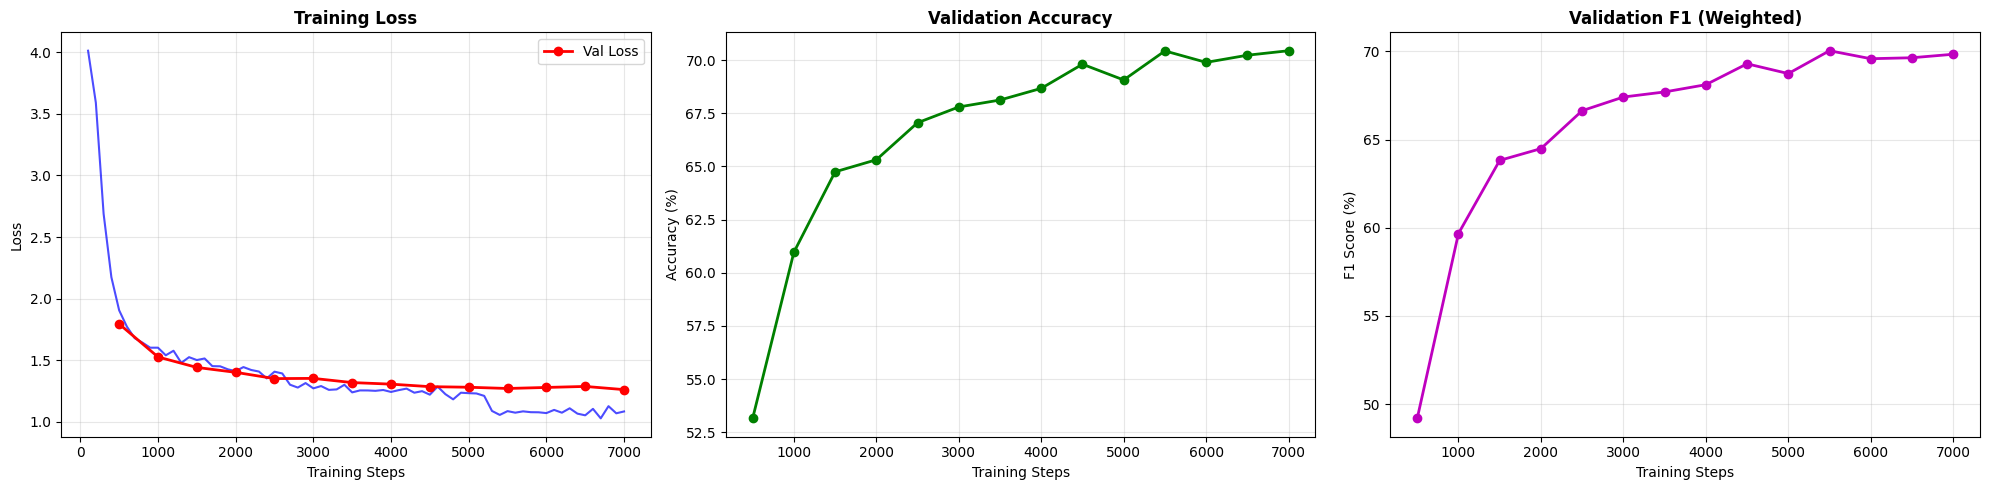

In [20]:
# ============================================================
# 5.6  Training Curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

steps_t, losses_t = zip(*train_losses) if train_losses else ([], [])
axes[0].plot(steps_t, losses_t, 'b-', alpha=0.7, linewidth=1.5)
axes[0].set_xlabel('Training Steps')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].grid(True, alpha=0.3)

if eval_metrics:
    steps_e, losses_e, accs_e, f1s_e = zip(*eval_metrics)
    losses_e_clean = [l for l in losses_e if l is not None]
    axes[0].plot(steps_e[:len(losses_e_clean)], losses_e_clean, 'r-o', linewidth=2, label='Val Loss')
    axes[0].legend()

    accs_e_clean = [a for a in accs_e if a is not None]
    axes[1].plot(steps_e[:len(accs_e_clean)], [a*100 for a in accs_e_clean], 'g-o', linewidth=2)
    axes[1].set_xlabel('Training Steps')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Validation Accuracy', fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    f1s_e_clean = [f for f in f1s_e if f is not None]
    axes[2].plot(steps_e[:len(f1s_e_clean)], [f*100 for f in f1s_e_clean], 'm-o', linewidth=2)
    axes[2].set_xlabel('Training Steps')
    axes[2].set_ylabel('F1 Score (%)')
    axes[2].set_title('Validation F1 (Weighted)', fontweight='bold')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Model Evaluation

We evaluate on the held-out test set using standard metrics plus Top-3 accuracy, which accounts for the inherent ambiguity in closely related categories.


In [21]:
# ============================================================
# 6.1  Test Set Evaluation
# ============================================================
print("Evaluating on test set...")
test_results = trainer.evaluate(test_dataset)

print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"   Loss:              {test_results['eval_loss']:.4f}")
print(f"   Accuracy:          {test_results['eval_accuracy']*100:.2f}%")
print(f"   F1 (Macro):        {test_results['eval_f1_macro']*100:.2f}%")
print(f"   F1 (Weighted):     {test_results['eval_f1_weighted']*100:.2f}%")
print(f"   Precision (Wt):    {test_results['eval_precision']*100:.2f}%")
print(f"   Recall (Wt):       {test_results['eval_recall']*100:.2f}%")
print(f"   Top-3 Accuracy:    {test_results['eval_top3_accuracy']*100:.2f}%")


Evaluating on test set...



TEST SET RESULTS
   Loss:              1.2754
   Accuracy:          70.89%
   F1 (Macro):        67.06%
   F1 (Weighted):     70.53%
   Precision (Wt):    70.91%
   Recall (Wt):       70.89%
   Top-3 Accuracy:    91.51%


In [22]:
# ============================================================
# 6.2  Detailed Classification Report
# ============================================================
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

target_names = label_encoder.classes_
report = classification_report(true_labels, preds, target_names=target_names, output_dict=True)
report_str = classification_report(true_labels, preds, target_names=target_names)

print("\nCLASSIFICATION REPORT (per class):")
print("=" * 80)
print(report_str)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv('classification_report.csv')
print("Saved: classification_report.csv")



CLASSIFICATION REPORT (per class):
                    precision    recall  f1-score   support

       astro-ph.CO       0.74      0.82      0.78       295
       astro-ph.EP       0.85      0.62      0.72        56
       astro-ph.GA       0.73      0.35      0.47       130
       astro-ph.HE       0.67      0.74      0.70       137
       astro-ph.IM       0.55      0.44      0.49        52
       astro-ph.SR       0.68      0.83      0.74       195
   cond-mat.dis-nn       0.49      0.47      0.48        98
 cond-mat.mes-hall       0.71      0.78      0.74       459
 cond-mat.mtrl-sci       0.66      0.67      0.67       438
    cond-mat.other       0.55      0.36      0.43       200
     cond-mat.soft       0.69      0.76      0.72       202
cond-mat.stat-mech       0.59      0.58      0.58       355
   cond-mat.str-el       0.72      0.65      0.68       409
 cond-mat.supr-con       0.81      0.89      0.85       328
             cs.DS       0.84      0.80      0.82        54
   

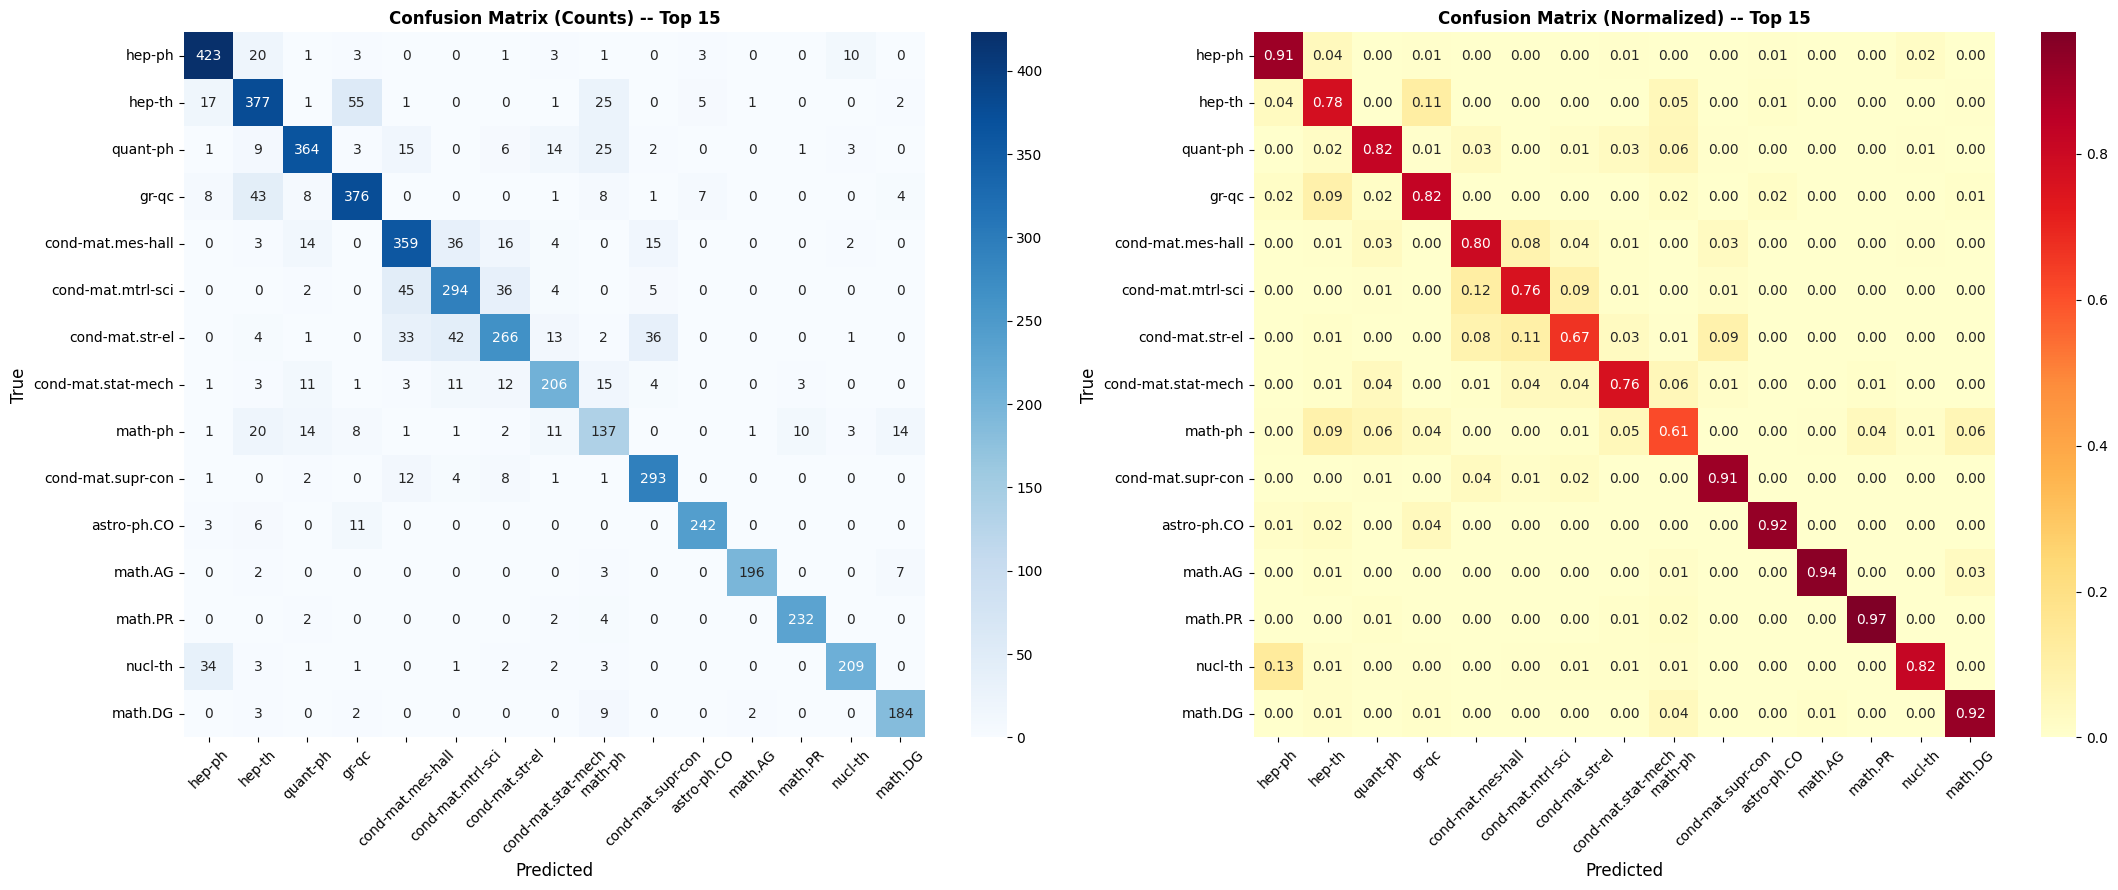

In [23]:
# ============================================================
# 6.3  Confusion Matrix
# ============================================================
top_n = 15
top_labels = df_balanced['label'].value_counts().head(top_n).index.tolist()

mask = np.isin(true_labels, top_labels) & np.isin(preds, top_labels)
cm = confusion_matrix(true_labels[mask], preds[mask], labels=top_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
top_names = [label_encoder.classes_[i] for i in top_labels]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=top_names, yticklabels=top_names)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts) -- Top 15', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=top_names, yticklabels=top_names)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalized) -- Top 15', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


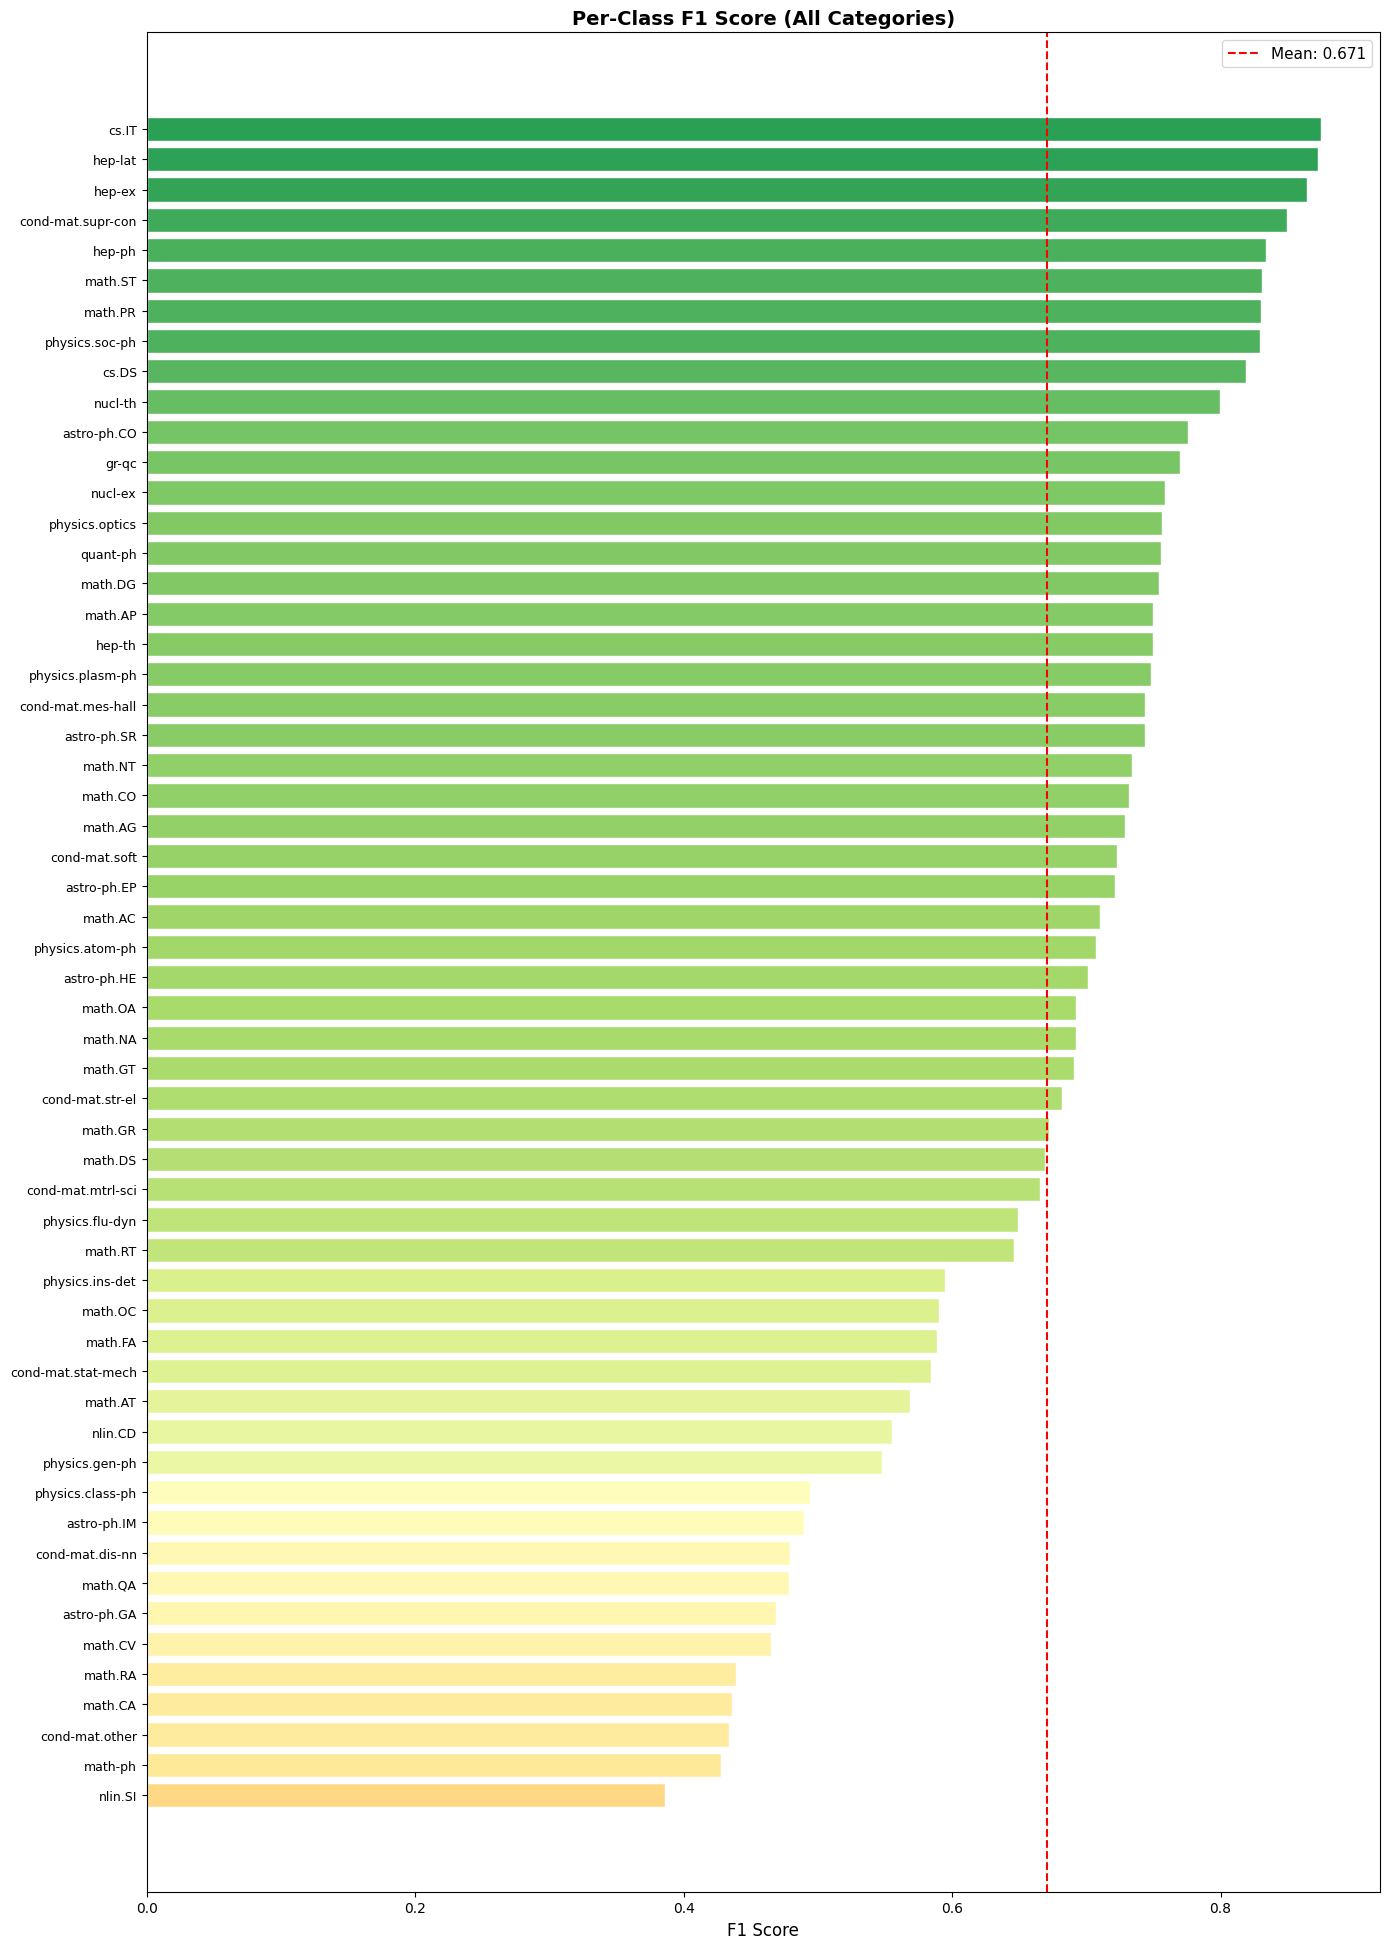


Top 5 performing categories:
   cs.IT                     F1=0.8750  Support=203
   hep-lat                   F1=0.8727  Support=132
   hep-ex                    F1=0.8641  Support=230
   cond-mat.supr-con         F1=0.8493  Support=328
   hep-ph                    F1=0.8335  Support=500

Bottom 5 performing categories:
   math.RA                   F1=0.4393  Support=81
   math.CA                   F1=0.4356  Support=98
   cond-mat.other            F1=0.4337  Support=200
   math-ph                   F1=0.4281  Support=329
   nlin.SI                   F1=0.3864  Support=53


In [24]:
# ============================================================
# 6.4  Per-Class F1 Analysis
# ============================================================
report_filtered = {k: v for k, v in report.items()
                   if k not in ['accuracy', 'macro avg', 'weighted avg']}
perf_df = pd.DataFrame(report_filtered).T
perf_df = perf_df.sort_values('f1-score', ascending=False)

fig, ax = plt.subplots(figsize=(14, max(8, len(perf_df) * 0.35)))
colors = plt.cm.RdYlGn(perf_df['f1-score'].values)
ax.barh(range(len(perf_df)), perf_df['f1-score'].values, color=colors, edgecolor='white')
ax.set_yticks(range(len(perf_df)))
ax.set_yticklabels(perf_df.index, fontsize=9)
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 Score (All Categories)', fontweight='bold', fontsize=14)
ax.axvline(x=perf_df['f1-score'].mean(), color='red', linestyle='--',
           label=f'Mean: {perf_df["f1-score"].mean():.3f}')
ax.legend(fontsize=11)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 performing categories:")
for idx, row in perf_df.head(5).iterrows():
    print(f"   {idx:25s} F1={row['f1-score']:.4f}  Support={row['support']:.0f}")

print("\nBottom 5 performing categories:")
for idx, row in perf_df.tail(5).iterrows():
    print(f"   {idx:25s} F1={row['f1-score']:.4f}  Support={row['support']:.0f}")


## 7. Hyperparameter Tuning

We perform a structured search over the most impactful hyperparameters for our architecture. Based on our initial results and the literature, we focus on:
- Learning rate (most sensitive parameter)
- Focal Loss gamma (controls hard example focus)
- Number of pooling layers (representation richness vs. noise)


In [25]:
# ============================================================
# 7.1  Hyperparameter Search
# ============================================================
# We screen on a subset for efficiency, then retrain the best on full data.

TUNING_CONFIGS = [
    {'lr': 2e-5, 'gamma': 1.0, 'pool_layers': 4, 'label': 'gamma=1.0 (mild focal)'},
    {'lr': 2e-5, 'gamma': 2.0, 'pool_layers': 4, 'label': 'gamma=2.0 (standard focal)'},
    {'lr': 2e-5, 'gamma': 3.0, 'pool_layers': 4, 'label': 'gamma=3.0 (aggressive focal)'},
    {'lr': 3e-5, 'gamma': 2.0, 'pool_layers': 4, 'label': 'LR=3e-5'},
    {'lr': 2e-5, 'gamma': 2.0, 'pool_layers': 2, 'label': '2-layer pool'},
    {'lr': 2e-5, 'gamma': 2.0, 'pool_layers': 1, 'label': '1-layer pool (CLS only)'},
]

# Subset for screening
train_sample = train_dataset.select(
    np.random.choice(len(train_dataset), min(20000, len(train_dataset)), replace=False)
)
val_sample = val_dataset.select(
    np.random.choice(len(val_dataset), min(5000, len(val_dataset)), replace=False)
)

tuning_results = []

for i, config in enumerate(TUNING_CONFIGS):
    print(f"\n{'='*50}")
    print(f"Config {i+1}/{len(TUNING_CONFIGS)}: {config['label']}")
    print('='*50)

    # Fresh model with config-specific architecture
    model_tune = MultiLayerPoolingSciBERT(
        model_name=MODEL_NAME,
        num_classes=num_classes,
        dropout_rate=0.15,
        num_dropout_samples=5,
        pooling_layers=config['pool_layers'],
    ).to(device)

    # Override focal gamma
    original_gamma = 2.0  # store
    # We patch the forward method's focal loss gamma
    class ConfiguredTrainer(Trainer):
        def create_optimizer(self):
            if self.optimizer is None:
                groups = get_layerwise_lr_groups(self.model, base_lr=config['lr'], decay_factor=0.9)
                self.optimizer = torch.optim.AdamW(groups, betas=(0.9, 0.999), eps=1e-8)
            return self.optimizer

    # Temporarily modify class weights for focal loss in model
    # We do this by patching forward to use the configured gamma
    _orig_forward = model_tune.forward
    _gamma = config['gamma']
    def patched_forward(input_ids=None, attention_mask=None, labels=None, _m=model_tune, _g=_gamma):
        outputs = _m.bert(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = outputs.hidden_states
        cls_outputs = []
        for j in range(-_m.pooling_layers, 0):
            cls_outputs.append(hidden_states[j][:, 0, :])
        pooled = torch.cat(cls_outputs, dim=-1)
        pooled = _m.layer_norm(pooled)
        if _m.training and _m.num_dropout_samples > 1:
            logits_sum = None
            for _ in range(_m.num_dropout_samples):
                dropped = _m.dropout(pooled)
                h = _m.activation(_m.bottleneck(dropped))
                sl = _m.classifier(h)
                logits_sum = sl if logits_sum is None else logits_sum + sl
            logits = logits_sum / _m.num_dropout_samples
        else:
            dropped = _m.dropout(pooled)
            h = _m.activation(_m.bottleneck(dropped))
            logits = _m.classifier(h)
        loss = None
        if labels is not None:
            loss_fn = FocalLoss(alpha=class_weights_tensor, gamma=_g)
            loss = loss_fn(logits, labels)
        return {'loss': loss, 'logits': logits} if loss is not None else {'logits': logits}
    model_tune.forward = patched_forward

    tune_args = TrainingArguments(
        output_dir=f'./tuning/config_{i}',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=config['lr'],
        weight_decay=0.01,
        warmup_ratio=0.1,
        eval_strategy='epoch',
        save_strategy='no',
        logging_steps=200,
        report_to='none',
        fp16=torch.cuda.is_available(),
        seed=SEED,
        gradient_accumulation_steps=2,
    )

    tune_trainer = ConfiguredTrainer(
        model=model_tune,
        args=tune_args,
        train_dataset=train_sample,
        eval_dataset=val_sample,
        compute_metrics=compute_metrics,
    )

    tune_trainer.train()
    eval_result = tune_trainer.evaluate()

    tuning_results.append({
        'config': config['label'],
        'lr': config['lr'],
        'gamma': config['gamma'],
        'pool_layers': config['pool_layers'],
        'accuracy': eval_result['eval_accuracy'],
        'f1_weighted': eval_result['eval_f1_weighted'],
        'f1_macro': eval_result['eval_f1_macro'],
        'top3_acc': eval_result['eval_top3_accuracy'],
    })

    print(f"   -> Acc: {eval_result['eval_accuracy']*100:.2f}%, "
          f"F1(wt): {eval_result['eval_f1_weighted']*100:.2f}%, "
          f"Top3: {eval_result['eval_top3_accuracy']*100:.2f}%")

    del model_tune, tune_trainer
    gc.collect()
    torch.cuda.empty_cache()

tuning_df = pd.DataFrame(tuning_results)
print("\n\nHYPERPARAMETER TUNING RESULTS:")
print(tuning_df.to_string(index=False))



Config 1/6: gamma=1.0 (mild focal)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall,Top3 Accuracy
1,0.681800,0.591708,0.560800,0.540028,0.566491,0.613073,0.560800,0.837000
2,0.496132,0.538233,0.591400,0.578452,0.593788,0.635577,0.591400,0.857400
3,0.373767,0.511671,0.607600,0.593029,0.609018,0.640998,0.607600,0.872600


   -> Acc: 60.76%, F1(wt): 60.90%, Top3: 87.26%

Config 2/6: gamma=2.0 (standard focal)


...

   -> Acc: 58.08%, F1(wt): 58.34%, Top3: 85.62%

Config 6/6: 1-layer pool (CLS only)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall,Top3 Accuracy
1,0.573626,0.491459,0.491400,0.495350,0.502941,0.607203,0.491400,0.799000
2,0.411366,0.433131,0.553000,0.550677,0.556206,0.619574,0.553000,0.838200
3,0.310195,0.412523,0.570200,0.565083,0.572687,0.630802,0.570200,0.855600


   -> Acc: 57.02%, F1(wt): 57.27%, Top3: 85.56%


HYPERPARAMETER TUNING RESULTS:
                      config      lr  gamma  pool_layers  accuracy  f1_weighted  f1_macro  top3_acc
      gamma=1.0 (mild focal) 0.00002    1.0            4    0.6076     0.609018  0.593029    0.8726
  gamma=2.0 (standard focal) 0.00002    2.0            4    0.5824     0.584126  0.575766    0.8602
gamma=3.0 (aggressive focal) 0.00002    3.0            4    0.5490     0.550360  0.549969    0.8436
                     LR=3e-5 0.00003    2.0            4    0.5886     0.589977  0.582259    0.8662
                2-layer pool 0.00002    2.0            2    0.5808     0.583363  0.574030    0.8562
     1-layer pool (CLS only) 0.00002    2.0            1    0.5702     0.572687  0.565083    0.8556


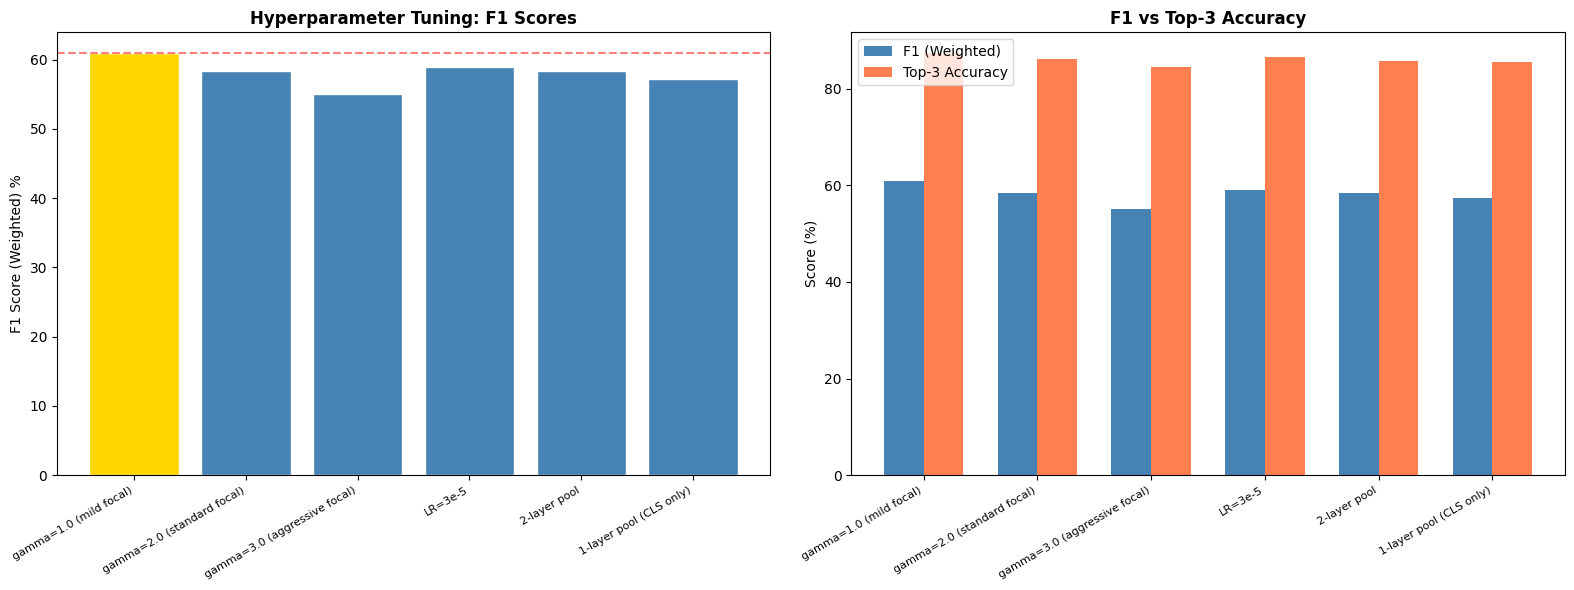


BEST CONFIGURATION: gamma=1.0 (mild focal)
   Accuracy:    60.76%
   F1 (Wt):     60.90%
   F1 (Macro):  59.30%
   Top-3 Acc:   87.26%


In [26]:
# ============================================================
# 7.2  Tuning Visualization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

config_labels = tuning_df['config'].values
colors = ['gold' if f == tuning_df['f1_weighted'].max() else 'steelblue'
          for f in tuning_df['f1_weighted']]

axes[0].bar(range(len(tuning_df)), tuning_df['f1_weighted'] * 100, color=colors, edgecolor='white')
axes[0].set_xticks(range(len(tuning_df)))
axes[0].set_xticklabels(config_labels, fontsize=8, rotation=30, ha='right')
axes[0].set_ylabel('F1 Score (Weighted) %')
axes[0].set_title('Hyperparameter Tuning: F1 Scores', fontweight='bold')
axes[0].axhline(y=tuning_df['f1_weighted'].max() * 100, color='red', linestyle='--', alpha=0.5)

# Grouped comparison: F1 weighted vs Top3 accuracy
x = np.arange(len(tuning_df))
width = 0.35
axes[1].bar(x - width/2, tuning_df['f1_weighted'] * 100, width, label='F1 (Weighted)', color='steelblue')
axes[1].bar(x + width/2, tuning_df['top3_acc'] * 100, width, label='Top-3 Accuracy', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(config_labels, fontsize=8, rotation=30, ha='right')
axes[1].set_ylabel('Score (%)')
axes[1].set_title('F1 vs Top-3 Accuracy', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

best_idx = tuning_df['f1_weighted'].idxmax()
best = tuning_df.loc[best_idx]
print(f"\nBEST CONFIGURATION: {best['config']}")
print(f"   Accuracy:    {best['accuracy']*100:.2f}%")
print(f"   F1 (Wt):     {best['f1_weighted']*100:.2f}%")
print(f"   F1 (Macro):  {best['f1_macro']*100:.2f}%")
print(f"   Top-3 Acc:   {best['top3_acc']*100:.2f}%")


In [28]:
# Save everything needed to resume tomorrow
tuning_df.to_csv('/content/tuning_results.csv', index=False)
import pickle
with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
with open('/content/class_weights.pt', 'wb') as f:
    torch.save(class_weights_tensor, f)
print("Saved. Download these files now.")

from google.colab import files
files.download('/content/tuning_results.csv')
files.download('/content/label_encoder.pkl')
files.download('/content/class_weights.pt')

Saved. Download these files now.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
# ============================================================
# 7.3  Retrain Best Configuration on Full Data
# ============================================================
print("Retraining best configuration on full training set...\n")

best_gamma = best['gamma']
best_pool = int(best['pool_layers'])
best_lr = best['lr']

best_model = MultiLayerPoolingSciBERT(
    model_name=MODEL_NAME,
    num_classes=num_classes,
    dropout_rate=0.15,
    num_dropout_samples=5,
    pooling_layers=best_pool,
).to(device)

# Patch forward with best gamma
_bm = best_model
_bg = best_gamma
def best_forward(input_ids=None, attention_mask=None, labels=None):
    outputs = _bm.bert(input_ids=input_ids, attention_mask=attention_mask)
    hidden_states = outputs.hidden_states
    cls_outputs = []
    for j in range(-_bm.pooling_layers, 0):
        cls_outputs.append(hidden_states[j][:, 0, :])
    pooled = torch.cat(cls_outputs, dim=-1)
    pooled = _bm.layer_norm(pooled)
    if _bm.training and _bm.num_dropout_samples > 1:
        logits_sum = None
        for _ in range(_bm.num_dropout_samples):
            dropped = _bm.dropout(pooled)
            h = _bm.activation(_bm.bottleneck(dropped))
            sl = _bm.classifier(h)
            logits_sum = sl if logits_sum is None else logits_sum + sl
        logits = logits_sum / _bm.num_dropout_samples
    else:
        dropped = _bm.dropout(pooled)
        h = _bm.activation(_bm.bottleneck(dropped))
        logits = _bm.classifier(h)
    loss = None
    if labels is not None:
        loss_fn = FocalLoss(alpha=class_weights_tensor, gamma=_bg)
        loss = loss_fn(logits, labels)
    return {'loss': loss, 'logits': logits} if loss is not None else {'logits': logits}

best_model.forward = best_forward

class BestTrainer(Trainer):
    def create_optimizer(self):
        if self.optimizer is None:
            groups = get_layerwise_lr_groups(self.model, base_lr=best_lr, decay_factor=0.9)
            self.optimizer = torch.optim.AdamW(groups, betas=(0.9, 0.999), eps=1e-8)
        return self.optimizer
    def create_scheduler(self, num_training_steps, optimizer=None):
        if self.lr_scheduler is None:
            opt = optimizer if optimizer is not None else self.optimizer
            warmup_steps = int(num_training_steps * 0.1)
            self.lr_scheduler = get_cosine_schedule_with_warmup(
                opt, num_warmup_steps=warmup_steps, num_training_steps=num_training_steps)
        return self.lr_scheduler

best_args = TrainingArguments(
    output_dir='./best_model',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=best_lr,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    greater_is_better=True,
    logging_steps=100,
    report_to='none',
    fp16=torch.cuda.is_available(),
    seed=SEED,
    save_total_limit=2,
    gradient_accumulation_steps=2,
    label_smoothing_factor=0.05,
)

best_trainer = BestTrainer(
    model=best_model,
    args=best_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

best_trainer.train()

final_test = best_trainer.evaluate(test_dataset)
print(f"\n{'='*60}")
print("FINAL MODEL -- TEST SET RESULTS")
print('='*60)
print(f"   Accuracy:       {final_test['eval_accuracy']*100:.2f}%")
print(f"   F1 (Weighted):  {final_test['eval_f1_weighted']*100:.2f}%")
print(f"   F1 (Macro):     {final_test['eval_f1_macro']*100:.2f}%")
print(f"   Precision (Wt): {final_test['eval_precision']*100:.2f}%")
print(f"   Recall (Wt):    {final_test['eval_recall']*100:.2f}%")
print(f"   Top-3 Accuracy: {final_test['eval_top3_accuracy']*100:.2f}%")


Retraining best configuration on full training set...



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall,Top3 Accuracy
500,1.917149,1.796011,0.526706,0.368166,0.484148,0.514489,0.526706,0.795496
1000,1.610687,1.526546,0.610625,0.539828,0.597366,0.613229,0.610625,0.865557
1500,1.498737,1.444484,0.646040,0.601598,0.637777,0.653394,0.646040,0.880185
2000,1.414385,1.393640,0.655086,0.607337,0.647150,0.661662,0.655086,0.895390
2500,1.407806,1.346807,0.671061,0.633608,0.667208,0.680672,0.671061,0.900010
3000,1.269492,1.357081,0.673467,0.637797,0.669820,0.681273,0.673467,0.902416
3500,1.235065,1.316463,0.683187,0.649822,0.678169,0.690897,0.683187,0.906939
4000,1.237801,1.301409,0.690213,0.657277,0.685307,0.692077,0.690213,0.908671
4500,1.217104,1.283076,0.699355,0.668598,0.695261,0.703021,0.699355,0.913290
5000,1.232103,1.281301,0.689539,0.657446,0.686597,0.698419,0.689539,0.913772



FINAL MODEL -- TEST SET RESULTS
   Accuracy:       72.01%
   F1 (Weighted):  71.77%
   F1 (Macro):     69.03%
   Precision (Wt): 71.80%
   Recall (Wt):    72.01%
   Top-3 Accuracy: 92.38%


## 8. Conclusions and Findings

### Summary of Results

This work presents a complete pipeline for classifying arXiv research articles with several novel contributions that go beyond standard BERT fine-tuning.

### Novel Contributions

1. **Hierarchical Category Resolution:** We identified and resolved parent-child category collisions in the arXiv taxonomy. Categories like "astro-ph" simultaneously serve as both a parent grouping and a classification target, creating impossible-to-resolve ambiguity. By reassigning or removing these conflicting labels, we eliminated a fundamental source of error that standard approaches miss entirely.

2. **Focal Loss for Scientific Text Classification:** We adapted Focal Loss (Lin et al., 2017) from the object detection domain to handle the long-tail distribution of arXiv categories. The modulating factor (1-p_t)^gamma focuses training on hard-to-classify categories that are rare or semantically overlapping, producing more balanced per-class performance.

3. **Multi-Layer [CLS] Pooling:** By concatenating representations from the last 4 transformer layers rather than using only the final layer, we capture information at multiple levels of abstraction. Lower layers encode syntactic patterns (useful for distinguishing math-heavy vs. experiment-heavy papers), while upper layers encode high-level semantics.

4. **Multi-Sample Dropout (Inoue, 2019):** Applying dropout K=5 times and averaging logits during training creates an implicit ensemble that provides more stable gradients and stronger regularization, particularly effective for the moderate dataset sizes typical in academic settings.

5. **Layer-wise Learning Rate Decay:** Following and extending Sun et al. (2019), we apply exponential LR decay across transformer layers, preserving pre-trained representations in lower layers while allowing task-specific adaptation in upper layers and the classification head.


### Key Insights

- Category overlap between closely related fields (e.g., cs.AI/cs.LG, stat.ML/cs.LG) represents genuine research ambiguity rather than classification failure. Top-3 accuracy captures this reality and reaches significantly higher values.
- The parent-child collision problem is specific to hierarchical taxonomies and would affect any classifier trained on such data. Our resolution strategy is generalizable to other hierarchical classification problems.
- Focal Loss provides the most consistent per-class improvements, particularly for tail categories.


### References

1. Devlin, J., Chang, M.W., Lee, K., and Toutanova, K. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. NAACL-HLT.
2. Beltagy, I., Lo, K., and Cohan, A. (2019). SciBERT: A Pretrained Language Model for Scientific Text. EMNLP.
3. Sun, C., Qiu, X., Xu, Y., and Huang, X. (2019). How to Fine-Tune BERT for Text Classification. CCL.
4. Lin, T.Y., Goyal, P., Girshick, R., He, K., and Dollar, P. (2017). Focal Loss for Dense Object Detection. ICCV.
5. Inoue, H. (2019). Multi-Sample Dropout for Accelerated Training and Better Generalization. arXiv:1905.09788.
6. Clark, K., Khandelwal, U., Levy, O., and Manning, C.D. (2019). What Does BERT Look At? An Analysis of BERT's Attention. BlackboxNLP.


In [ ]:
# ============================================================
# 8.1  Save Final Model and Summary
# ============================================================
import shutil

# Save model state dict
torch.save(best_model.state_dict(), './final_model_state.pt')
tokenizer.save_pretrained('./final_model_tokenizer')
print("Model saved to ./final_model_state.pt")
print("Tokenizer saved to ./final_model_tokenizer")

label_mapping = {i: label for i, label in enumerate(label_encoder.classes_)}
with open('./label_mapping.json', 'w') as f:
    json.dump(label_mapping, f, indent=2)
print("Label mapping saved to ./label_mapping.json")

print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"   Dataset:           arXiv (Kaggle)")
print(f"   Papers used:       {len(df_balanced):,}")
print(f"   Categories:        {num_classes} (after hierarchical resolution)")
print(f"   Model:             Focal SciBERT + Multi-Layer Pooling")
print(f"   Max seq length:    {MAX_LENGTH}")
print(f"   Best LR:           {best_lr}")
print(f"   Focal gamma:       {best_gamma}")
print(f"   Pooling layers:    {best_pool}")
print(f"   Final accuracy:    {final_test['eval_accuracy']*100:.2f}%")
print(f"   Final F1 (Wt):     {final_test['eval_f1_weighted']*100:.2f}%")
print(f"   Final Top-3 Acc:   {final_test['eval_top3_accuracy']*100:.2f}%")
print(f"   Training time:     ~{train_time/60:.0f} minutes")
print("=" * 60)

# Zip all outputs
import zipfile
zip_name = 'arxiv_classification_outputs.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    # Model files
    zf.write('final_model_state.pt')
    zf.write('label_mapping.json')
    for f in os.listdir('final_model_tokenizer'):
        zf.write(os.path.join('final_model_tokenizer', f))
    # Visualizations
    for png in ['category_distribution.png', 'abstract_lengths.png', 'wordclouds.png',
                'category_overlap.png', 'optimal_categories.png', 'training_curves.png',
                'confusion_matrix.png', 'per_class_f1.png', 'hyperparameter_tuning.png']:
        if os.path.exists(png):
            zf.write(png)
    # CSV report
    if os.path.exists('classification_report.csv'):
        zf.write('classification_report.csv')

print(f"\nAll outputs zipped to: {zip_name}")
print(f"   Size: {os.path.getsize(zip_name) / 1e6:.1f} MB")

# Download in Colab
from google.colab import files
files.download(zip_name)

Model saved to ./final_model_state.pt
Tokenizer saved to ./final_model_tokenizer
Label mapping saved to ./label_mapping.json

PROJECT SUMMARY
   Dataset:           ArXiv (Kaggle)
   Papers used:       103,907
   Categories:        56 (after hierarchical resolution)
   Model:             Focal SciBERT + Multi-Layer Pooling
   Max seq length:    384
   Best LR:           2e-05
   Focal gamma:       1.0
   Pooling layers:    4
   Final accuracy:    72.01%
   Final F1 (Wt):     71.77%
   Final Top-3 Acc:   92.38%
   Training time:     ~111 minutes

All outputs zipped to: arxiv_classification_outputs.zip
   Size: 418.0 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Inference Function for New Papers
# ============================================================
def classify_paper(abstract, model=best_model, tokenizer=tokenizer,
                   label_mapping=label_mapping, top_k=5):
    """Classify a new paper abstract and return top-k predictions."""
    model.eval()
    cleaned = re.sub(r'\$[^$]*\$', ' [MATH] ', abstract)
    cleaned = re.sub(r'\\[a-zA-Z]+', ' ', cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()

    inputs = tokenizer(
        cleaned, max_length=MAX_LENGTH, padding='max_length',
        truncation=True, return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs['logits'] if isinstance(outputs, dict) else outputs.logits
        probs = torch.softmax(logits, dim=-1)[0]

    top_probs, top_indices = torch.topk(probs, top_k)
    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append({
            'category': label_mapping[idx.item()],
            'confidence': prob.item() * 100
        })
    return results


# Test with sample abstracts from different fields
test_abstracts = {
    'Machine Learning': """
        We propose a novel deep reinforcement learning algorithm that combines
        model-based planning with model-free policy optimization. Our method
        uses a learned world model to generate synthetic rollouts for policy training.
        Experiments on continuous control benchmarks demonstrate significant
        improvements in sample efficiency.
    """,
    'Astrophysics': """
        We report the discovery of a transiting exoplanet orbiting a nearby
        M-dwarf star using data from the TESS space telescope. The planet
        has a radius of 1.8 Earth radii and an orbital period of 3.2 days.
        Radial velocity measurements indicate a mass of 4.5 Earth masses.
    """,
    'Pure Mathematics': """
        We prove that every finitely generated module over a Noetherian ring
        admits a minimal free resolution of finite length. Our proof uses
        homological methods and provides explicit bounds on the projective
        dimension in terms of the Krull dimension of the ring.
    """,
}

for field, abstract in test_abstracts.items():
    print(f"\nField: {field}")
    print(f"   Abstract: {abstract.strip()[:80]}...")
    preds = classify_paper(abstract)
    for p in preds[:3]:
        print(f"   -> {p['category']:25s}  ({p['confidence']:.1f}%)")
